**L'idée est ici de regrouper un cetain nombre d'informations sur les offres que proposent les groupes pour ensuite former une classification des types d'offres**

**Préparation de l'environnement**

In [330]:
# Nettoyage complet
print("Nettoyage...")
%reset -f

%whos

Nettoyage...
Interactive namespace is empty.


In [331]:
import pyodbc
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
import hdbscan
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
import re
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.stats import kruskal
import matplotlib.pyplot as plt
import requests
import os
from scipy.stats import f_oneway
import gc
from sklearn.preprocessing import StandardScaler
from datetime import datetime, timedelta

**Préparation des données**

In [332]:
conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=172.16.11.34;"
    "DATABASE=LogiProDev;"
    "UID=quentin;"
    "PWD={Barbidur1;SQL}"
)

conn = pyodbc.connect(conn_str)
cursor = conn.cursor()

# Les requêtes sont très longues pour éviter de sélectionner trop de données évidemment faussées. 
# Par exemple à chaque fois on vérifie que les données qu'on sélectionnes sont issues d'un groupe qui est
# actif, mais pas seulement : g.groupe_actif est un premier filtrage mais on vérifie quand même que le 
# groupe est réellement actif, c'est à dire au moins une offre et au moins une transaction. Pour les 
# négociateurs, on vérifie qu'ils viennent bien d'une agence active, etc. 

requete_groupes = """ 
-- Sous-requête : nombre d'offres et surface totale par groupe
with offres as (
    select 
        groupe_id,
        count(offre_id) as nb_offres,
        sum(off_surface_totale) as surface_totale
    from t_offre
    where off_actif = 1
    group by groupe_id
),
transactions as (
    select distinct groupe_id
    from t_transaction
)
select 
    g.groupe_id,
    g.gro_nom,
    g.gro_date_creation,
    o.nb_offres,
    o.surface_totale as surface_totale_a_proposer,
    count(distinct a.agence_id) as nb_agences,
    cast(o.nb_offres as float) / nullif(count(distinct a.agence_id), 0) as moy_offres_par_agence
from t_groupe g
inner join offres o
    on g.groupe_id = o.groupe_id
inner join transactions t
    on g.groupe_id = t.groupe_id
left join t_agence a
    on a.groupe_id = g.groupe_id
where g.gro_actif = 1
    and g.groupe_id != 0
group by 
    g.groupe_id,
    g.gro_nom,
    g.gro_date_creation,
    o.nb_offres,
    o.surface_totale
"""

requete_complementaire_groupes_negociateurs = """ 
select 
    n.groupe_id,
    n.negociateur_id
from 
    t_negociateur n
inner join t_groupe g
    on g.groupe_id = n.groupe_id
    and g.gro_actif = 1
inner join t_offre o
    on o.groupe_id = g.groupe_id
    and o.off_actif = 1
inner join t_transaction t
    on t.groupe_id = g.groupe_id
where
    n.neg_date_creation is not null
    and n.groupe_id != 0
group by
    n.groupe_id,
    n.negociateur_id
"""

requete_complementaire_groupes_transactions = """ 
select 
    t.groupe_id,
    t.transaction_id, 
    t.tra_surface
from 
    t_transaction t
where 
    t.groupe_id != 0
    and exists (
        select 1
        from t_groupe g
        inner join t_offre o 
            on o.groupe_id = g.groupe_id
            and o.off_actif = 1
        inner join t_transaction t2
            on t2.groupe_id = g.groupe_id
        where g.gro_actif = 1
        and g.groupe_id = t.groupe_id
    )
"""

requete_agences = """
select 
    a.agence_id,
    a.groupe_id
from 
    t_agence a
where
    a.age_actif = 1
    and a.groupe_id != 0
    and exists (
        select 1
        from t_groupe g
        inner join t_offre o 
            on o.groupe_id = g.groupe_id
            and o.off_actif = 1
        inner join t_transaction t
            on t.groupe_id = g.groupe_id
        where g.gro_actif = 1
        and g.groupe_id = a.groupe_id
    )
"""

requete_complementaire_agences_negociateurs = """
select 
    n.negociateur_id,
    n.agence_id,
    n.groupe_id
from 
    t_negociateur n
where
    n.neg_actif = 1
    and n.neg_date_creation is not null
    and n.groupe_id != 0
    and exists (
        select 1
        from t_groupe g
        inner join t_offre o 
            on o.groupe_id = g.groupe_id
            and o.off_actif = 1
        inner join t_transaction t
            on t.groupe_id = g.groupe_id
        where g.gro_actif = 1
        and g.groupe_id = n.groupe_id
    )
"""

requete_complementaire_agences_offres = """ 
select 
    o.offre_id,
    o.agence_id,
    o.groupe_id
from 
    t_offre o
inner join t_groupe g
    on g.groupe_id = o.groupe_id
    and g.gro_actif = 1
where
    o.off_actif = 1
    and o.groupe_id != 0
"""

requete_complementaire_agences_transactions = """ 
select 
    t.transaction_id, 
    t.groupe_id,
    t.negociateur_id, 
    t.agence_id,
    t.tra_date_signature,
    t.tra_surface,
    n.neg_date_creation
from 
    t_transaction t
left join t_negociateur n
    on n.negociateur_id = t.negociateur_id
inner join t_groupe g
    on g.groupe_id = t.groupe_id
    and g.gro_actif = 1
where 
    n.neg_date_creation is not null
    and n.groupe_id != 0
"""

requete_negociateurs = """ 
select 
    n.negociateur_id,
    n.agence_id,
    n.neg_date_creation
from 
    t_negociateur n
inner join t_agence a
    on a.agence_id = n.agence_id
    and a.age_actif = 1
where
    n.neg_actif = 1
    and n.neg_date_creation is not null
    and n.groupe_id != 0
    and exists (
        select 1
        from t_groupe g
        inner join t_offre o 
            on o.groupe_id = g.groupe_id
            and o.off_actif = 1
        inner join t_transaction t
            on t.groupe_id = g.groupe_id
        where g.gro_actif = 1
          and g.groupe_id = n.groupe_id
    )
"""

requete_offres = """
select 
    o.offre_id, 
    o.langue_id, 
    o.negociateur_id, 
    o.offre_type_id, 
    o.agence_id, 
    o.groupe_id, 
    o.nature_offre_id,
    o.off_date_creation,
    o.off_surface_totale,
    o.off_surface_indivisible,
    count(ol.lot_id) as nb_lots
from t_offre o
left join tj_offre_lot ol 
    on o.offre_id = ol.offre_id
left join t_negociateur n
    on n.negociateur_id = o.negociateur_id
where 
    o.off_actif = 1 
    and n.neg_date_creation is not null
    and o.groupe_id != 0
    and exists (
        select 1
        from t_transaction t
        where t.groupe_id = o.groupe_id
    )
group by
    o.offre_id, 
    o.langue_id, 
    o.negociateur_id, 
    o.offre_type_id, 
    o.agence_id, 
    o.groupe_id, 
    o.nature_offre_id,
    o.off_date_creation,
    o.off_surface_totale,
    o.off_surface_indivisible
"""

# On l'importe en premier car il sera utile pour créer une des colonnes du dataset agences
dataset_offres = pd.read_sql_query(requete_offres, conn)

# Le principal intéressé
dataset_agences = pd.read_sql_query(requete_agences, conn)

# On récupère le département de l'agence, feature importante pour compter le nombre de transactions qui se font en dehors de ce dernier
localisations_agences = pd.read_excel("localisations_agences.xlsx")
localisations_agences = localisations_agences[["agence_nom", "agence_id", "latitude", "longitude", "agence_code_postal"]]
localisations_agences["agence_code_postal"] = localisations_agences["agence_code_postal"].astype(str)
localisations_agences["departement"] = localisations_agences["agence_code_postal"].str[:2]

localisations_agences = localisations_agences[localisations_agences["agence_nom"] != "Marion"]
localisations_agences = localisations_agences[localisations_agences["agence_nom"] != "Valérie"]
localisations_agences = localisations_agences[localisations_agences["agence_nom"] != "ARTHUR LOYD LOGISTIQUE"]
localisations_agences = localisations_agences[localisations_agences["agence_nom"] != "DBX Test new descro"]
localisations_agences = localisations_agences[localisations_agences["agence_nom"] != "Agence Commerce"]
localisations_agences = localisations_agences[localisations_agences["agence_nom"] != "Agence Activité"]
localisations_agences = localisations_agences[localisations_agences["agence_nom"] != "Colliers Confidentiel"]
localisations_agences = localisations_agences[localisations_agences["agence_id"] != "0"]

# On s'intéressera aussi au nombre d'offres à disposition dans cette agence
dataset_complementaire_agences_offres = pd.read_sql_query(requete_complementaire_agences_offres, conn)
nb_offres_par_agence = dataset_complementaire_agences_offres.groupby("agence_id")["offre_id"].count().reset_index()
nb_offres_par_agence = nb_offres_par_agence.rename(columns={"offre_id": "nb_offres"})
dataset_agences = dataset_agences.merge(nb_offres_par_agence, how="left", on="agence_id")
dataset_agences["nb_offres"] = dataset_agences["nb_offres"].fillna(0).astype(int)

# Ainsi qu'au nombre de négociateurs qui sont là pour s'en occuper
dataset_complementaire_agences_negociateurs = pd.read_sql_query(requete_complementaire_agences_negociateurs, conn)
nb_negociateurs_par_agence = dataset_complementaire_agences_negociateurs.groupby("agence_id")["negociateur_id"].nunique().reset_index()
nb_negociateurs_par_agence = nb_negociateurs_par_agence.rename(columns={"negociateur_id": "nb_negociateurs"})
dataset_agences = dataset_agences.merge(nb_negociateurs_par_agence, how="left", on="agence_id")

# De la surface qui est à proposer au total
surface_par_agence = dataset_offres.groupby("agence_id")["off_surface_totale"].sum().reset_index()
surface_par_agence = surface_par_agence.rename(columns={"off_surface_totale": "surface_totale_a_proposer"})
dataset_agences = dataset_agences.merge(surface_par_agence, how="left", on="agence_id")
dataset_agences["surface_totale_a_proposer"] = dataset_agences["surface_totale_a_proposer"].fillna(0)

# Quelques ratios parce que c'est toujours important pour comparer
dataset_agences["surface_a_proposer_par_nego"] = dataset_agences["surface_totale_a_proposer"] / dataset_agences["nb_negociateurs"].replace(0, np.nan)
dataset_agences["nb_moyen_offres_par_nego"] = dataset_agences["nb_offres"] / dataset_agences["nb_negociateurs"].replace(0, np.nan)

# On ne prend en compte que les transactions de l'année qui vient de s'écouler
dataset_complementaire_agences_transactions= pd.read_sql_query(requete_complementaire_agences_transactions, conn)
dataset_complementaire_agences_transactions["tra_date_signature"] = pd.to_datetime(dataset_complementaire_agences_transactions["tra_date_signature"])
un_an = datetime.today() - timedelta(days=365)
dataset_complementaire_agences_transactions = dataset_complementaire_agences_transactions[dataset_complementaire_agences_transactions["tra_date_signature"] >= un_an]
nb_transacs_agence = dataset_complementaire_agences_transactions.groupby("agence_id")["transaction_id"].count().reset_index()
nb_transacs_agence = nb_transacs_agence.rename(columns={"transaction_id" : "nb_transacs"})
dataset_agences = dataset_agences.merge(nb_transacs_agence[["agence_id", "nb_transacs"]], how="left", on="agence_id")
dataset_agences["nb_transacs_par_nego"] = dataset_agences["nb_transacs"] / dataset_agences["nb_negociateurs"].replace(0, np.nan)

# Et comme on n'a pas la donnée de la commission que s'est pris l'agence sur la transaction, on retient la surface comme métrique principale
surface_totale_transactionnee = dataset_complementaire_agences_transactions.groupby("agence_id")["tra_surface"].sum().reset_index()
surface_totale_transactionnee = surface_totale_transactionnee.rename(columns={"tra_surface" : "surface_totale_transactionnee"})
dataset_agences = dataset_agences.merge(surface_totale_transactionnee, how="left", on="agence_id")
dataset_agences["surface_transactionnee_moyenne_par_nego"] = dataset_agences["surface_totale_transactionnee"] / dataset_agences["nb_negociateurs"].replace(0, np.nan)
dataset_agences["surface_moyenne_par_transac"] = dataset_agences["surface_totale_transactionnee"] / dataset_agences["nb_transacs"].replace(0, np.nan)

# On libère la mémoire des objets qu'on ne va plus utiliser
del dataset_complementaire_agences_negociateurs
del dataset_complementaire_agences_offres
del nb_negociateurs_par_agence
del localisations_agences
del nb_offres_par_agence
del nb_transacs_agence
del surface_par_agence
del surface_totale_transactionnee
gc.collect()

# On explore à présent sur les groupes
dataset_groupes = pd.read_sql_query(requete_groupes, conn)
dataset_complementaire_groupes_transactions = pd.read_sql_query(requete_complementaire_groupes_transactions, conn)

# Les transactions réalisées d'abord c'est une bonne métrique de performance
transactions_par_groupe = dataset_complementaire_groupes_transactions.groupby("groupe_id")["transaction_id"].count()
dataset_groupes = dataset_groupes.merge(transactions_par_groupe.rename("nb_transactions"), how="left", on="groupe_id")
dataset_groupes["nb_transactions"] = dataset_groupes["nb_transactions"].fillna(0).astype(int)
dataset_groupes["ratio_transacs_agences"] = dataset_groupes["nb_transactions"] / dataset_groupes["nb_agences"]

# L'ancienneté du groupe chez LGP, on ne sait jamais, peut-être que ça peut être utile
dataset_groupes["gro_date_creation"] = pd.to_datetime(dataset_groupes["gro_date_creation"])
dataset_groupes["gro_date_creation"] = (pd.Timestamp.today() - dataset_groupes["gro_date_creation"]).dt.days

# Toujours des ratios pour comparer
dataset_groupes["ratio_transacs_agences_duree"] = dataset_groupes["ratio_transacs_agences"] / dataset_groupes["gro_date_creation"]
dataset_complementaire_groupes_negociateurs = pd.read_sql_query(requete_complementaire_groupes_negociateurs, conn)
negociateurs_par_groupe = dataset_complementaire_groupes_negociateurs.groupby("groupe_id")["negociateur_id"].count()
dataset_groupes = dataset_groupes.merge(negociateurs_par_groupe.rename("nb_negociateurs"), how="left", on="groupe_id")
dataset_groupes["nb_negociateurs"] = dataset_groupes["nb_negociateurs"].fillna(0).astype(int)
dataset_groupes["ratio_transacs_negociateurs"] = dataset_groupes["nb_transactions"] / dataset_groupes["nb_negociateurs"]
dataset_groupes["ratio_negociateurs_agences"] = dataset_groupes["nb_negociateurs"] / dataset_groupes["nb_agences"]
dataset_groupes["ratio_surface_a_proposer_nego"] = dataset_groupes["surface_totale_a_proposer"] / dataset_groupes["nb_negociateurs"]
dataset_groupes["ratio_surface_a_proposer_agence"] = dataset_groupes["surface_totale_a_proposer"] / dataset_groupes["nb_agences"]

# On ajoute les données sur les transactions
surface_totale_transactionnee = dataset_complementaire_agences_transactions.groupby("groupe_id")["tra_surface"].sum().reset_index()
surface_totale_transactionnee = surface_totale_transactionnee.rename(columns={"tra_surface" : "surface_totale_transactionnee"})
dataset_groupes = dataset_groupes.merge(surface_totale_transactionnee, how="left", on="groupe_id")
dataset_groupes["surface_moyenne_par_transac"] = dataset_groupes["surface_totale_transactionnee"] / dataset_groupes["nb_transactions"].replace(0, np.nan)
dataset_groupes["surface_totale_moyenne_transac_par_nego"] = dataset_groupes["surface_totale_transactionnee"] / dataset_groupes["nb_negociateurs"].replace(0, np.nan)
dataset_groupes["surface_totale_moyenne_transactionnee_par_agence"] = dataset_groupes["surface_totale_transactionnee"] / dataset_groupes["nb_agences"].replace(0, np.nan)
dataset_groupes["surface_totale_moyenne_transactionnee_par_agence_par_transac"] = dataset_groupes["surface_totale_moyenne_transactionnee_par_agence"] / dataset_groupes["ratio_transacs_agences"].replace(0, np.nan)

# Et enfin on nettoie la mémoire
del negociateurs_par_groupe
del dataset_complementaire_groupes_negociateurs
del dataset_complementaire_groupes_transactions
del transactions_par_groupe
gc.collect()

# On enchaîne avec la même chose sur les négociateurs
dataset_negociateurs = pd.read_sql_query(requete_negociateurs, conn)
nego_nb_offres = dataset_offres.groupby("negociateur_id")["offre_id"].count().reset_index()
nego_nb_offres = nego_nb_offres.rename(columns={"offre_id" : "nb_offres"})
dataset_negociateurs.merge(nego_nb_offres, how="left", on="negociateur_id")
surface_par_nego = dataset_offres.groupby("negociateur_id")["off_surface_totale"].sum().reset_index()
surface_par_nego = surface_par_nego.rename(columns={"off_surface_totale" : "surface_totale_a_proposer_nego"})
dataset_negociateurs = dataset_negociateurs.merge(surface_par_nego, how="left", on="negociateur_id")
nb_transac_par_nego = dataset_complementaire_agences_transactions.groupby("negociateur_id")["tra_surface"].count().reset_index()
nb_transac_par_nego = nb_transac_par_nego.rename(columns={"tra_surface" : "nb_transacs"})
dataset_negociateurs = dataset_negociateurs.merge(nb_transac_par_nego, how="left", on="negociateur_id")
surface_totale_transactionnee_par_nego = dataset_complementaire_agences_transactions.groupby("negociateur_id")["tra_surface"].sum().reset_index()
surface_totale_transactionnee_par_nego = surface_totale_transactionnee_par_nego.rename(columns={"tra_surface" : "surface_totale_transactionnee"})
dataset_negociateurs = dataset_negociateurs.merge(surface_totale_transactionnee_par_nego, how="left", on="negociateur_id")
dataset_negociateurs["neg_date_creation"] = pd.to_datetime(dataset_negociateurs["neg_date_creation"])
dataset_negociateurs["neg_date_creation"] = (pd.Timestamp.today() - dataset_negociateurs["neg_date_creation"]).dt.days
dataset_negociateurs["ratio_surface_totale_transactionnee_temps_activite"] = dataset_negociateurs["surface_totale_transactionnee"] / dataset_negociateurs["neg_date_creation"].replace(0, np.nan)
dataset_negociateurs["ratio_nb_transacs_temps_activite"] = dataset_negociateurs["nb_transacs"] / dataset_negociateurs["neg_date_creation"].replace(0, np.nan)
dataset_negociateurs["surface_moyenne_par_transac"] = dataset_negociateurs["surface_totale_transactionnee"] / dataset_negociateurs["nb_transacs"].replace(0, np.nan)

del nego_nb_offres
del dataset_complementaire_agences_transactions
del surface_par_nego
del surface_totale_transactionnee_par_nego
gc.collect()

conn.commit()
cursor.close()
conn.close()

print(dataset_offres.columns)
print(dataset_groupes.columns)
print(dataset_agences.columns)
print(dataset_negociateurs.columns)

for colonne in dataset_offres.columns : 
    print(f"{colonne} : {dataset_offres[colonne].isna().sum()}")

for colonne in dataset_groupes.columns : 
    print(f"{colonne} : {dataset_groupes[colonne].isna().sum()}")

for colonne in dataset_agences.columns : 
    print(f"{colonne} : {dataset_agences[colonne].isna().sum()}")

for colonne in dataset_negociateurs.columns : 
    print(f"{colonne} : {dataset_negociateurs[colonne].isna().sum()}")

for dataset in [dataset_agences, dataset_offres, dataset_groupes, dataset_negociateurs] :
    colonnes_numeriques = dataset.select_dtypes(include=['float', 'int']).columns
    dataset[colonnes_numeriques] = dataset[colonnes_numeriques].fillna(0)

dataset_offres["off_date_creation"] = dataset_offres["off_date_creation"].fillna(method="ffill")

for colonne in dataset_offres.columns : 
    print(f"{colonne} : {dataset_offres[colonne].isna().sum()}")

for colonne in dataset_groupes.columns : 
    print(f"{colonne} : {dataset_groupes[colonne].isna().sum()}")

for colonne in dataset_agences.columns : 
    print(f"{colonne} : {dataset_agences[colonne].isna().sum()}")

for colonne in dataset_negociateurs.columns : 
    print(f"{colonne} : {dataset_negociateurs[colonne].isna().sum()}")

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\2194325646.py:252: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dataset_offres = pd.read_sql_query(requete_offres, conn)
C:\Users\quent\AppData\Local\Temp\ipykernel_11952\2194325646.py:255: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dataset_agences = pd.read_sql_query(requete_agences, conn)
C:\Users\quent\AppData\Local\Temp\ipykernel_11952\2194325646.py:273: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dataset_complementaire_agences_offres = pd.read_sql_query(requete_co

Index(['offre_id', 'langue_id', 'negociateur_id', 'offre_type_id', 'agence_id',
       'groupe_id', 'nature_offre_id', 'off_date_creation',
       'off_surface_totale', 'off_surface_indivisible', 'nb_lots'],
      dtype='object')
Index(['groupe_id', 'gro_nom', 'gro_date_creation', 'nb_offres',
       'surface_totale_a_proposer', 'nb_agences', 'moy_offres_par_agence',
       'nb_transactions', 'ratio_transacs_agences',
       'ratio_transacs_agences_duree', 'nb_negociateurs',
       'ratio_transacs_negociateurs', 'ratio_negociateurs_agences',
       'ratio_surface_a_proposer_nego', 'ratio_surface_a_proposer_agence',
       'surface_totale_transactionnee', 'surface_moyenne_par_transac',
       'surface_totale_moyenne_transac_par_nego',
       'surface_totale_moyenne_transactionnee_par_agence',
       'surface_totale_moyenne_transactionnee_par_agence_par_transac'],
      dtype='object')
Index(['agence_id', 'groupe_id', 'nb_offres', 'nb_negociateurs',
       'surface_totale_a_proposer', 's

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\2194325646.py:415: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dataset_offres["off_date_creation"] = dataset_offres["off_date_creation"].fillna(method="ffill")


**Clustering sur les négociateurs**

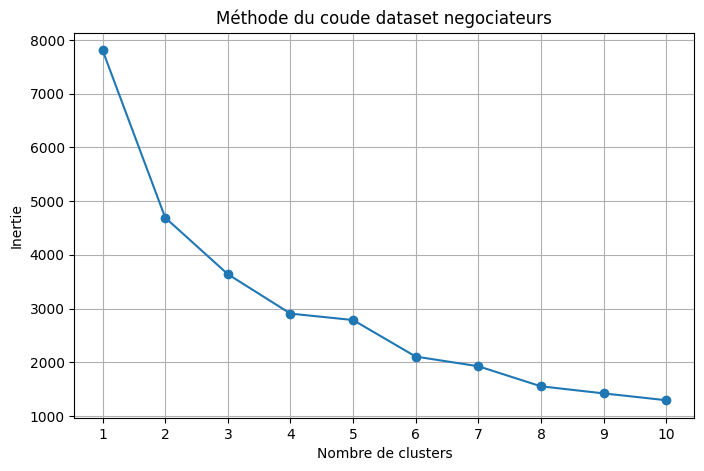

cluster
0    1182
3      87
2      27
1       6
Name: count, dtype: int64


C:\Users\quent\AppData\Local\Temp\ipykernel_11952\796912057.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset_negociateurs['cluster'] = kmeans.labels_


In [ ]:
# Maintenant on s'attaque vraiment au clustering
# On commence par le plus bas niveau : les négociateurs, puis les agences, puis les groupes

dataset_negociateurs = dataset_negociateurs[~dataset_negociateurs["negociateur_id"].isin([3906, 4166, 4810, 5461, 5662, 5326, 5602, 5656, 2643, 2716, 2872, 3169, 3372, 3793, 4117, 4138, 4274, 4433, 4614, 4615, 4672, 4681, 4870, 5560, 5561, 5570, 5587])]

colonnes_features_clustering_negos = [
    "surface_totale_a_proposer_nego",
    "nb_transacs",
    "surface_totale_transactionnee",
    "ratio_surface_totale_transactionnee_temps_activite",
    "ratio_nb_transacs_temps_activite",
    "surface_moyenne_par_transac"
]

inerties = []
k_range = range(1, 11)

X = dataset_negociateurs[colonnes_features_clustering_negos]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inerties.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inerties, marker='o')
plt.xlabel('Nombre de clusters')
plt.ylabel('Inertie')
plt.title("Méthode du coude dataset negociateurs")
plt.xticks(k_range)
plt.grid(True)
plt.show()

k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X_scaled)

dataset_negociateurs['cluster'] = kmeans.labels_

print(dataset_negociateurs['cluster'].value_counts())

In [334]:
# Code utilisé a posteriori pour retirer en amont les négociateurs qui faussent complètement les données

cluster_counts = dataset_negociateurs['cluster'].value_counts()
clusters_a_exclure = cluster_counts[cluster_counts < 6].index.tolist()
negociateurs_a_exclure = dataset_negociateurs[
    dataset_negociateurs['cluster'].isin(clusters_a_exclure)
]['negociateur_id'].tolist()
print("Negociateurs à exclure :", negociateurs_a_exclure)
print("Nombre :", len(negociateurs_a_exclure))

Negociateurs à exclure : []
Nombre : 0


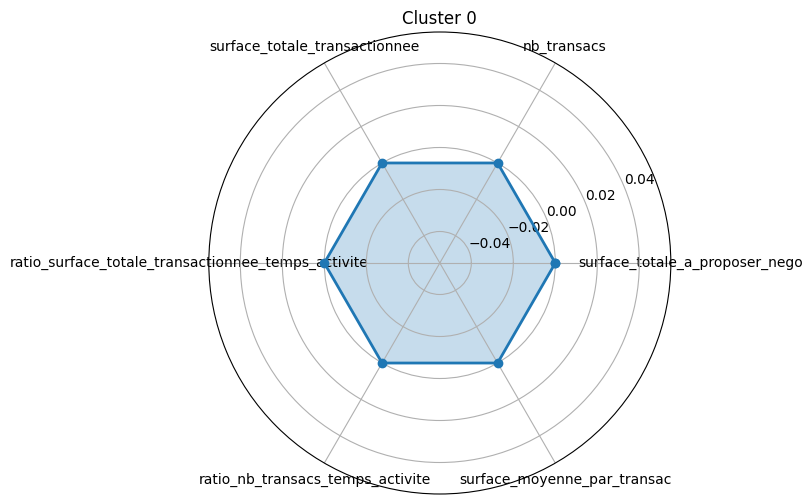

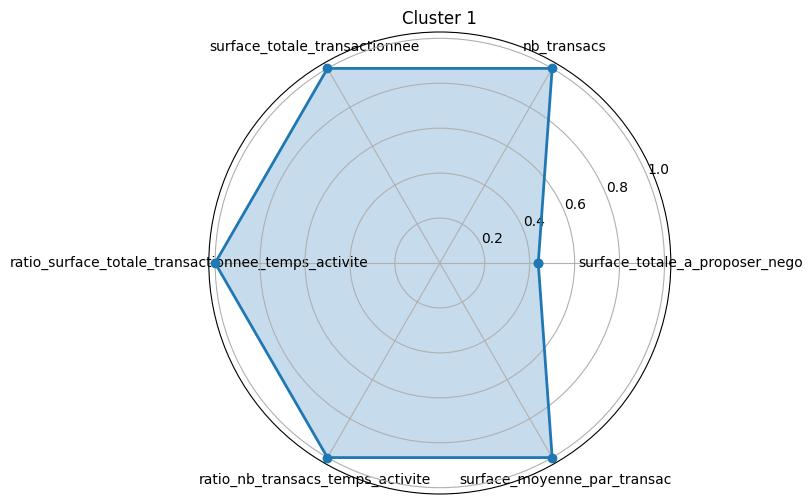

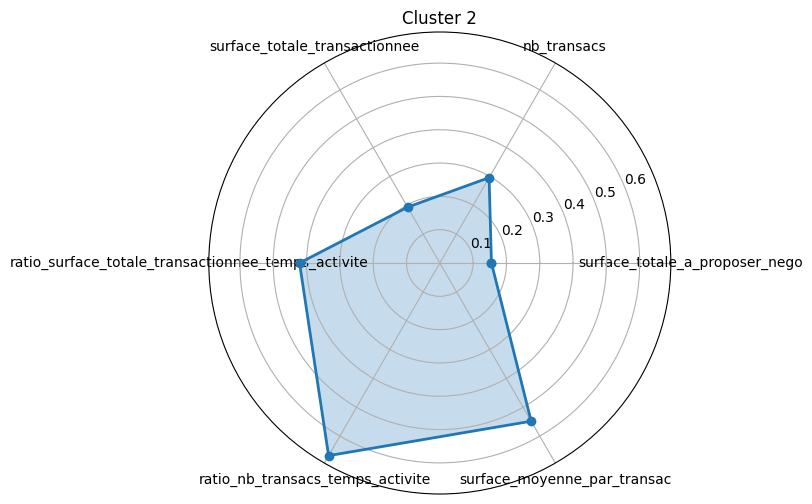

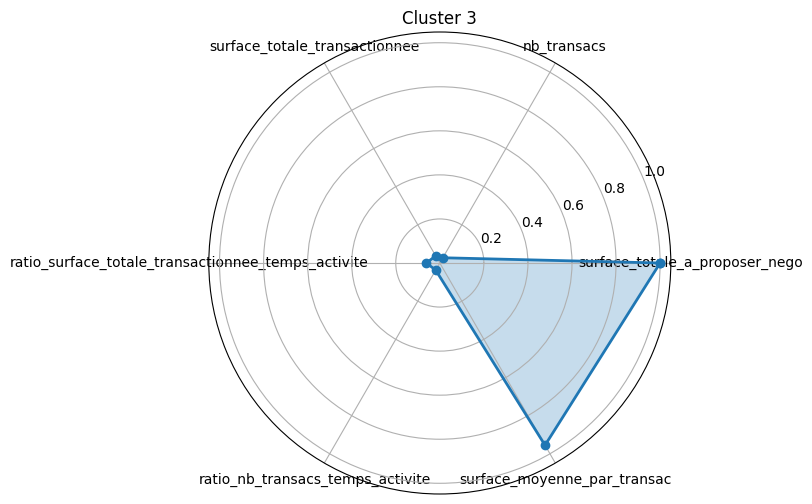

In [335]:
# On ajoute une colonne qui donne le cluster le plus représenté dans chaque agence pour le dataframe agences
cluster_majoritaire_par_agence = (
    dataset_negociateurs
    .groupby(['agence_id', 'cluster'])
    .size()  # compte combien de négociateurs par cluster dans chaque agence
    .reset_index(name='count')
)

cluster_majoritaire_par_agence = (
    cluster_majoritaire_par_agence
    .sort_values(['agence_id', 'count'], ascending=[True, False])
    .drop_duplicates(subset=['agence_id'], keep='first')
    .rename(columns={'cluster': 'cluster_nego_majoritaire'})
    [['agence_id', 'cluster_nego_majoritaire']]
)

dataset_agences = dataset_agences.merge(cluster_majoritaire_par_agence, on='agence_id', how='left')

cluster_means = dataset_negociateurs.groupby('cluster')[colonnes_features_clustering_negos].mean()
scaler = MinMaxScaler()
cluster_means_scaled = pd.DataFrame(scaler.fit_transform(cluster_means), columns=cluster_means.columns, index=cluster_means.index)

def plot_radar(cluster_id) :
    values = cluster_means_scaled.loc[cluster_id].values
    labels = cluster_means_scaled.columns
    N = len(labels)

    # Créer l’angle pour chaque feature
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    values = np.concatenate((values, [values[0]]))  # pour fermer le cercle
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
    ax.plot(angles, values, 'o-', linewidth=2)
    ax.fill(angles, values, alpha=0.25)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels)
    ax.set_title(f"Cluster {cluster_id}")
    ax.grid(True)
    plt.show()

for cluster_id in cluster_means_scaled.index:
    plot_radar(cluster_id)

Après avoir testé un paquet de types de clusterings différents et avoir essayé d'ajuster des manières classiques comme des plus exotiques qui soient les paramètres des clusterings, la seule conclusion à laquelle je réussis à parvenir est la suivante : les données sont EXTRÊMEMENT faussées. Les transactions ne sont pas toujours saisies, quand elles le sont elles ne le sont pas au nom du négociateur qui l'a réellement signée, les offres à proposer sont toutes regroupées sous le nom d'un même négociateur même quand ce n'est donc pas lui qui s'en occupe, etc. Même en retirant les outliers les plus évidents on a encore plus de 90% des négociateurs qui se retrouvent dans le même cluster...

On va quand même continuer l'analyse.

In [336]:
resume_moyennes = (
    dataset_negociateurs
    .groupby("cluster")[colonnes_features_clustering_negos]
    .mean()
)

print(resume_moyennes)

         surface_totale_a_proposer_nego  nb_transacs  \
cluster                                                
0                          7.790641e+04     1.713198   
1                          5.187571e+05   202.500000   
2                          2.338748e+05    61.111111   
3                          1.084154e+06     7.229885   

         surface_totale_transactionnee  \
cluster                                  
0                           469.396827   
1                        222837.250000   
2                         43526.065556   
3                          8782.318621   

         ratio_surface_totale_transactionnee_temps_activite  \
cluster                                                       
0                                                 0.313232    
1                                                62.055607    
2                                                26.313191    
3                                                 4.085926    

         ratio_nb_transacs_temp

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\882013070.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_negociateurs,


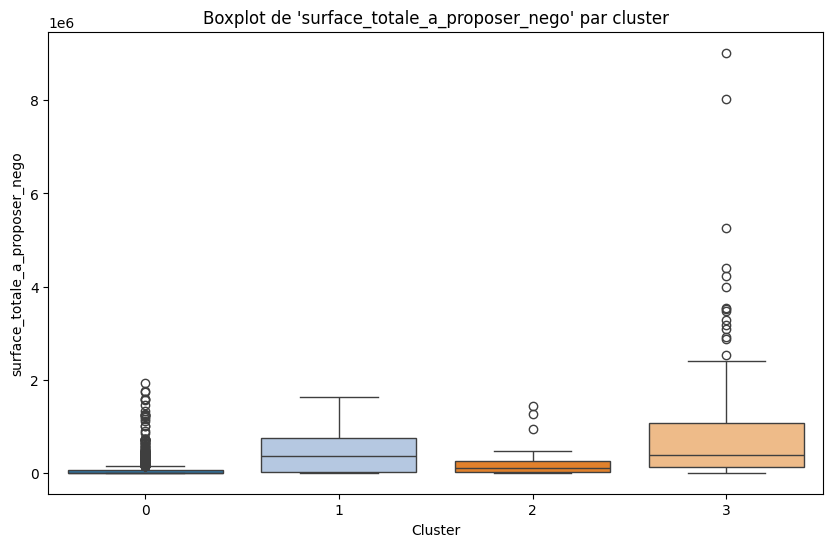

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\882013070.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_negociateurs,


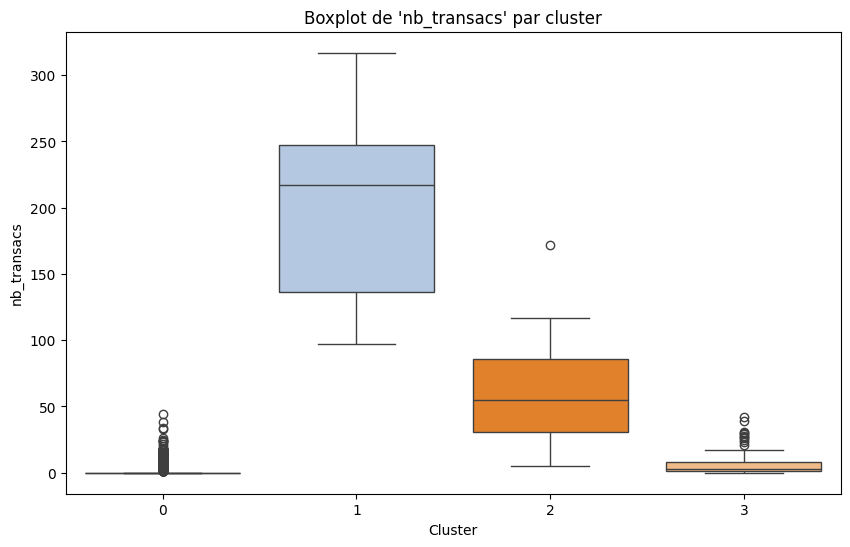

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\882013070.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_negociateurs,


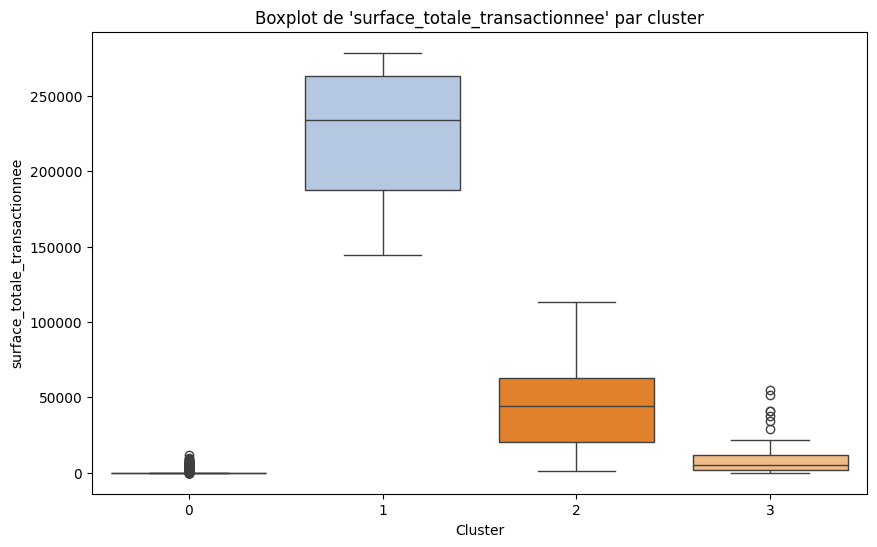

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\882013070.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_negociateurs,


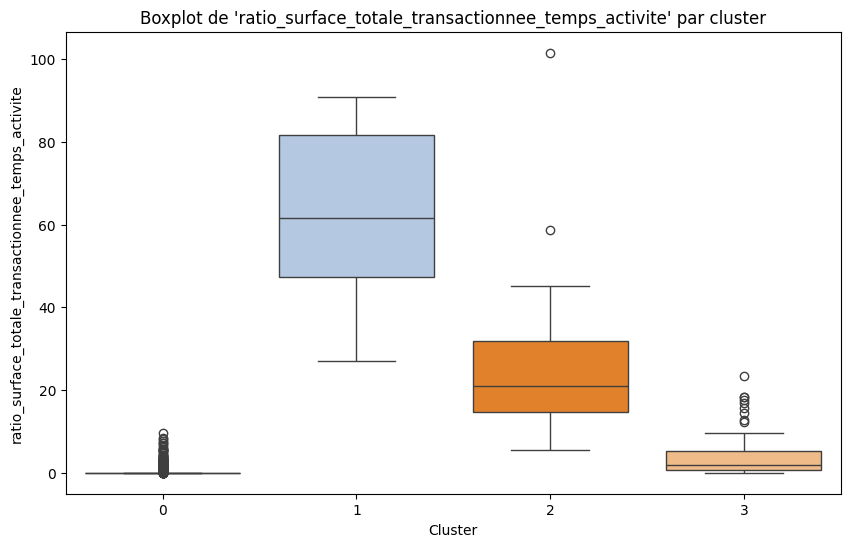

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\882013070.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_negociateurs,


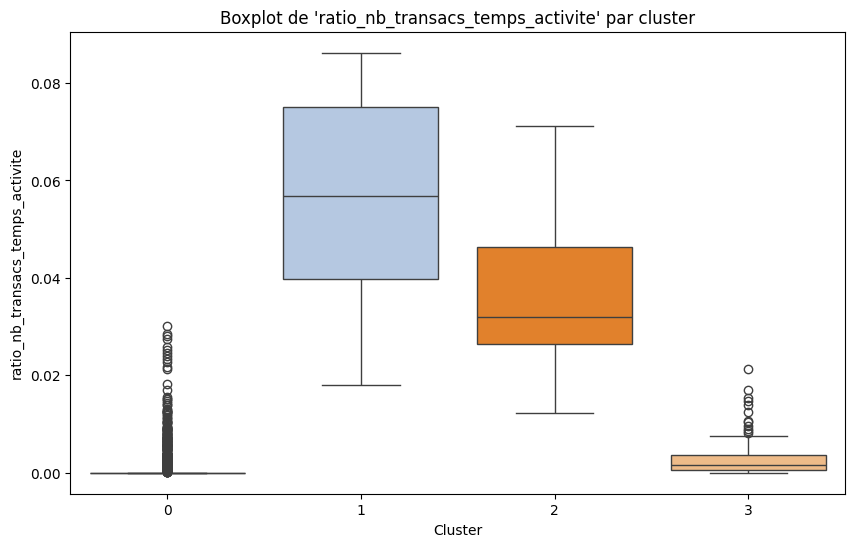

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\882013070.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_negociateurs,


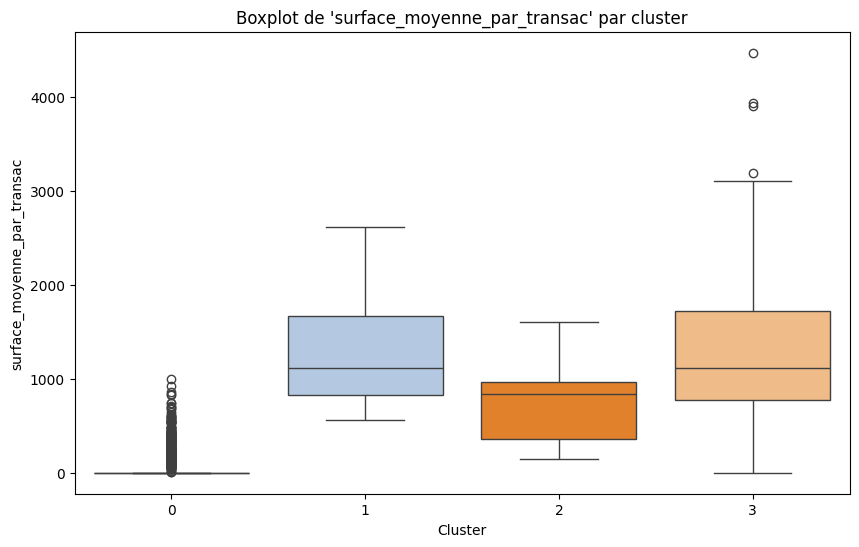

In [337]:
for feature in colonnes_features_clustering_negos :
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=dataset_negociateurs, 
                x="cluster", 
                y=feature, 
                palette="tab20")
    
    plt.title(f"Boxplot de '{feature}' par cluster")
    plt.xlabel("Cluster")
    plt.ylabel(feature)
    plt.show()


À regarder ces données, premier constat : 

Cluster 0 : 1336 points. Ce sont les négociateurs peu actifs. Peu de transactions, même rapportées au nombre de jours d'activité, toujours des petites surface, pas grand chose à proposer dans leur portefeuille

Cluster 1 : Les plus actifs. Ils ont beaucoup de surface à vendre, vendent souvent et des grosses surface.

Cluster 2 : Gèrent de très grandes surfaces mais signent peu de transactions.

Cluster 3 : Intensité de l'activité moyenne. Ils sont le continuum de négociateurs entre les hyperactifs et les amorphes. 

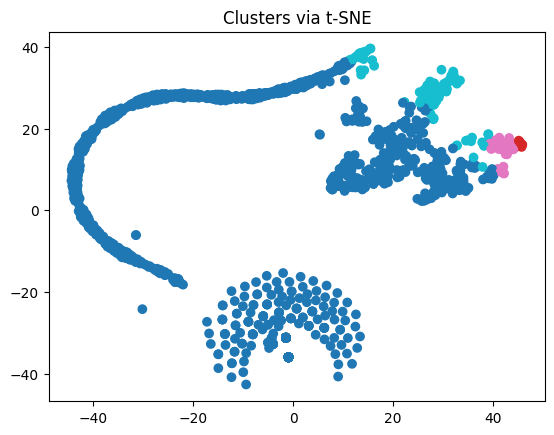

In [338]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=dataset_negociateurs["cluster"], cmap="tab10")
plt.title("Clusters via t-SNE")
plt.show()

df_tsne = pd.DataFrame({
    "tsne_x": X_tsne[:, 0],
    "tsne_y": X_tsne[:, 1],
    "cluster": dataset_negociateurs["cluster"].values
})

df_tsne = df_tsne[df_tsne["tsne_y"] > -100]

df_tsne.head()

conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=172.16.11.34;"
    "DATABASE=Superset;"
    "UID=quentin;"
    "PWD={Barbidur1;SQL}"
)

conn = pyodbc.connect(conn_str)
cursor = conn.cursor()

insert_query = """
    INSERT INTO cluster_negociateurs_tsne (tsne_x, tsne_y, cluster)
    VALUES (?, ?, ?)
"""

data_to_insert = list(df_tsne.itertuples(index=False, name=None))

cursor.executemany(insert_query, data_to_insert)

conn.commit()
conn.close()

Observer une telle structure est normal : on distingue les ultra actifs regroupés en bas, un quasi continuum de négociateurs normaux représentés par la ligne, et les négociateurs pour lesquels les données sont généralement mal saisies ou manquantes et qui se retrouvent donc avec beaucoup de features à zéro. 

Cette structure de PCA ui ne respecte pas la structure suggérée par les résultats du clustering est tout à fait normale car quand on projette en 2D des résultats qui étaient de base en 6D, des clusters bien séparés peuvent se retrouver mélangés (imaginer un cube dans lequel on dispose des points, avant de tout projeter dans le plan de la base du cube. Même si au départ on avait un paquet de points déjà disposés sur la base du cube sur laquelle on a projeté et un autre paquet à l'exact opposé du cube, à la fin on se retrouve avec tout mélangé).

Ci-dessous une projection 3D des données en 6D pour vérifier la séparation des clusters en écrasant moins les dimensions : 

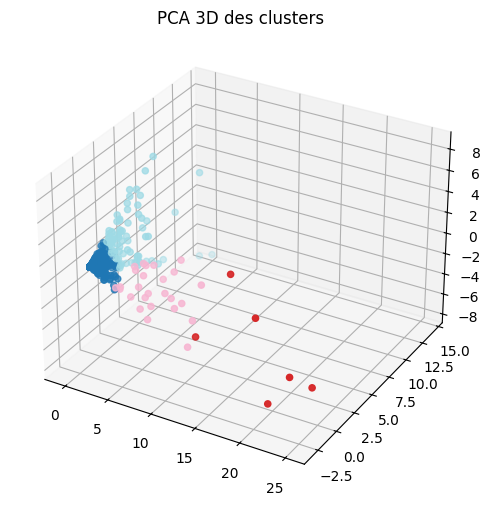

In [339]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2],
           c=dataset_negociateurs["cluster"], cmap="tab20", s=20)

ax.set_title("PCA 3D des clusters")
plt.show()

Cette observation confirme ce qui a été remarqué précédemment : un amas de négociateurs qui ont très peu de transactions, de surface à proposer, etc., deux groupes qui partent dans deu xdirections différentes, ceux qui gèrent de grandes surfaces mais signent peu de transactions, le continuum intermédiaire, et enfin les outliers constitués de quelques négociateurs anormalement hyperactifs. 

In [340]:
for feature in colonnes_features_clustering_negos:
    groups = [dataset_negociateurs[dataset_negociateurs.cluster == k][feature] for k in dataset_negociateurs.cluster.unique()]
    stat, p = f_oneway(*groups)
    print(feature, ": p =", p)

surface_totale_a_proposer_nego : p = 1.3813681961209086e-67
nb_transacs : p = 0.0
surface_totale_transactionnee : p = 0.0
ratio_surface_totale_transactionnee_temps_activite : p = 0.0
ratio_nb_transacs_temps_activite : p = 2.3664275211639833e-308
surface_moyenne_par_transac : p = 7.865536392458238e-227


Ce test (test Anova) teste : H0 : les clusters ont tous une moyenne égale sur cette variable contre H1 : au moins un cluster a une moyenne différente des autres. Bref, on attend une p-value faible si le clustering est concluant et sépare bien des points réellement différents. Ici on a carrément des p-values à 0, c'était inattendu au vu de la mauvaise qualité des données, mais le clustering est plus que concluant.

On confirme tout de même les résultats avec un autre test :

In [341]:
for feature in colonnes_features_clustering_negos:
    groups = [dataset_negociateurs[dataset_negociateurs.cluster == k][feature] for k in dataset_negociateurs.cluster.unique()]
    stat, p = kruskal(*groups)
    print(feature, ": p =", p)

surface_totale_a_proposer_nego : p = 3.4412042817775945e-37
nb_transacs : p = 1.2611679826716154e-58
surface_totale_transactionnee : p = 9.51037640341256e-74
ratio_surface_totale_transactionnee_temps_activite : p = 4.806651219029783e-72
ratio_nb_transacs_temps_activite : p = 6.746404079825123e-57
surface_moyenne_par_transac : p = 8.086116031109955e-77


Et les p-values sont toujours très proches de 0, c'est une excellente nouvelle.

Conclusion : les features séparent bien les clusters, les profils détectés ne sont pas des artefacts statistiques, ils correspondent à la réalité. 

**Clustering sur les agences à présent**

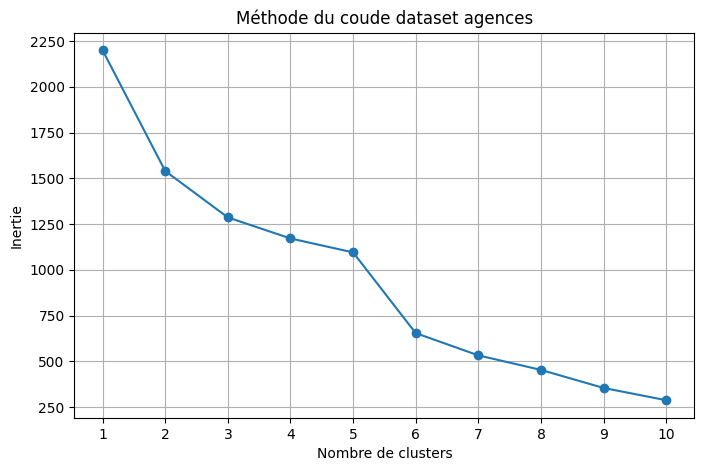

cluster
0    141
2     71
6      3
4      2
5      1
1      1
3      1
Name: count, dtype: int64


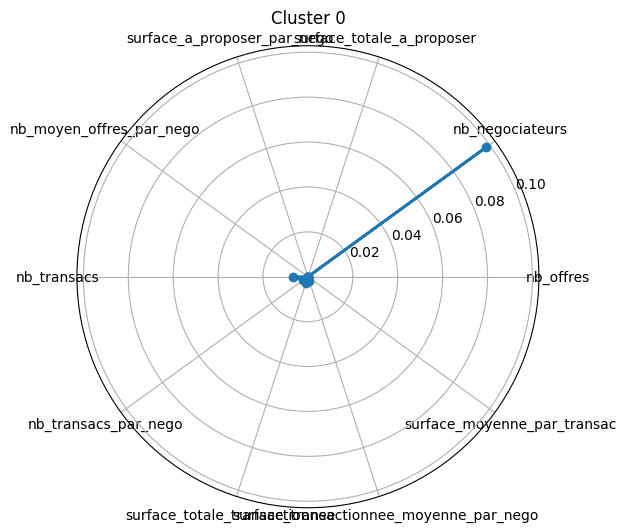

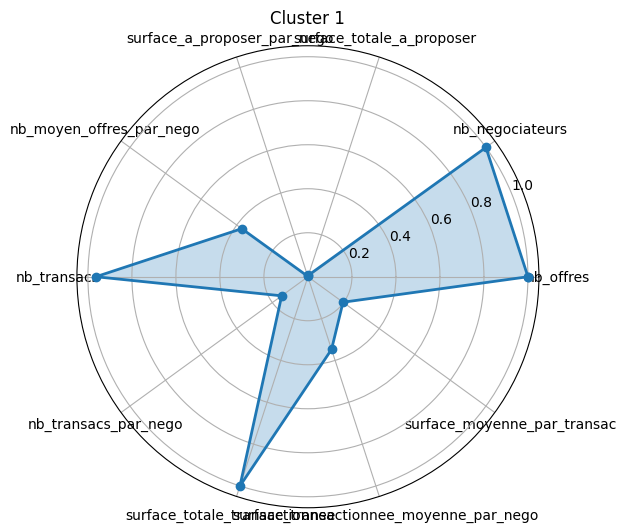

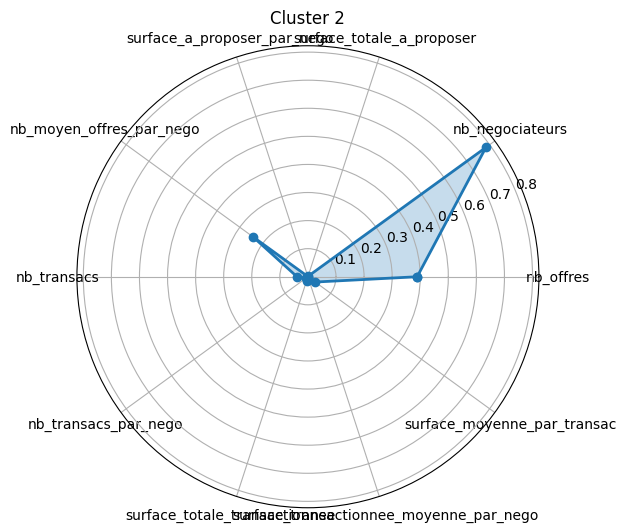

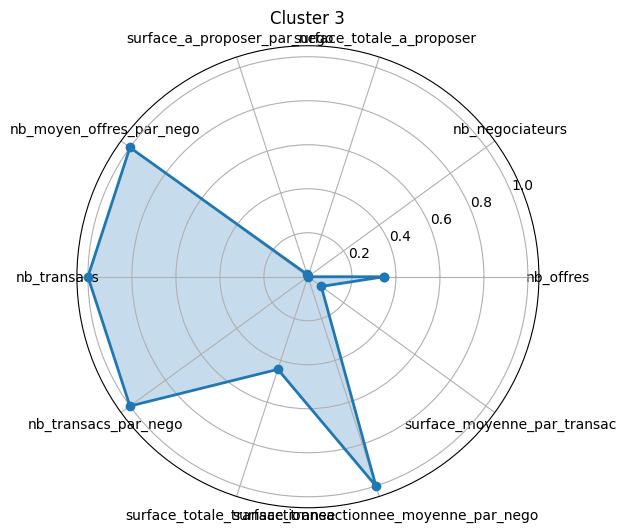

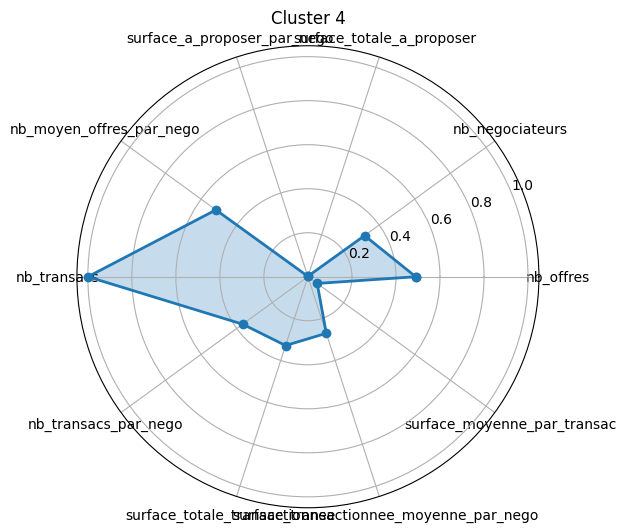

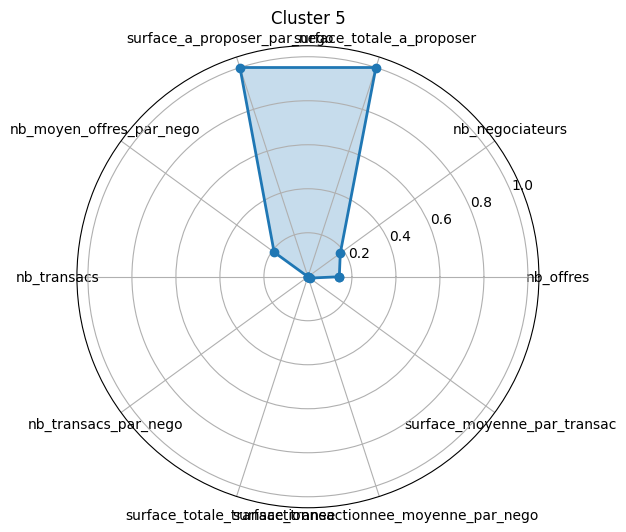

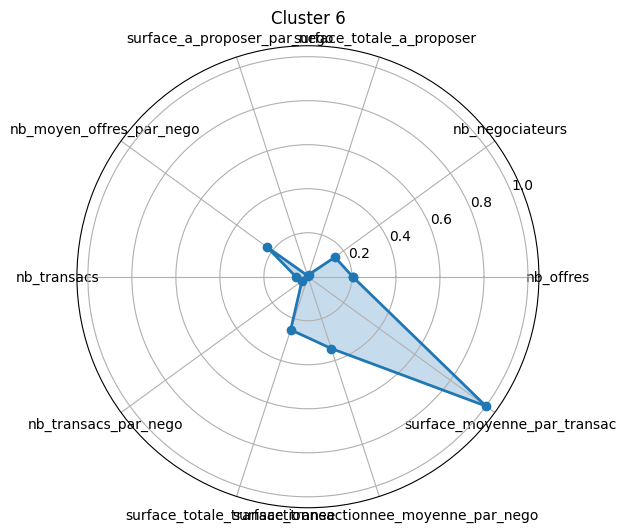

Index(['agence_id', 'groupe_id', 'nb_offres', 'nb_negociateurs',
       'surface_totale_a_proposer', 'surface_a_proposer_par_nego',
       'nb_moyen_offres_par_nego', 'nb_transacs', 'nb_transacs_par_nego',
       'surface_totale_transactionnee',
       'surface_transactionnee_moyenne_par_nego',
       'surface_moyenne_par_transac', 'cluster_nego_majoritaire', 'cluster'],
      dtype='object')


In [342]:
# Cette fois on a plus de features comme on est à un niveau plus élevé

colonnes_features_clustering_agences = [
    'nb_offres', 
    'nb_negociateurs',
    'surface_totale_a_proposer', 
    'surface_a_proposer_par_nego',
    'nb_moyen_offres_par_nego', 
    'nb_transacs', 
    'nb_transacs_par_nego',
    'surface_totale_transactionnee',
    'surface_transactionnee_moyenne_par_nego',
    'surface_moyenne_par_transac'
]

inerties = []
k_range = range(1, 11)

X = dataset_agences[colonnes_features_clustering_agences]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

for k in k_range :
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inerties.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inerties, marker='o')
plt.xlabel('Nombre de clusters')
plt.ylabel('Inertie')
plt.title("Méthode du coude dataset agences")
plt.xticks(k_range)
plt.grid(True)
plt.show()

# 3 et 7 fonctionnent pas trop mal. Prendre 4 et 5 revient juste à ajouter des clusters de bruit toujours
# moins peuplés
k = 7
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X_scaled)

dataset_agences['cluster'] = kmeans.labels_

print(dataset_agences['cluster'].value_counts())

cluster_means = dataset_agences.groupby('cluster')[colonnes_features_clustering_agences].mean()
scaler = MinMaxScaler()
cluster_means_scaled = pd.DataFrame(scaler.fit_transform(cluster_means), columns=cluster_means.columns, index=cluster_means.index)

for cluster_id in cluster_means_scaled.index:
    plot_radar(cluster_id)

print(dataset_agences.columns)

À première vue les spidercharts semblent déjà montrer des features plus discriminantes dans la constitution des clusters, même si on rencontre un problème similaire à celui des négociateurs : l'essentiel des agences sont regroupées dans un immense cluster et un cluster de taille plus modeste, tandis que les autres sont constitués de quasiment aucune agence... 

In [343]:
resume_moyennes = (
    dataset_agences
    .groupby("cluster")[colonnes_features_clustering_agences]
    .mean()
)

print(resume_moyennes)

           nb_offres  nb_negociateurs  surface_totale_a_proposer  \
cluster                                                            
0         119.163121         3.078014               3.531005e+05   
1        2734.000000        13.000000               7.474662e+06   
2        1136.464789        10.619718               2.157170e+06   
3        1024.000000         2.000000               5.821977e+06   
4        1400.000000         5.500000               3.289958e+06   
5         492.000000         4.000000               1.000696e+09   
6         650.666667         3.666667               1.001191e+07   

         surface_a_proposer_par_nego  nb_moyen_offres_par_nego  nb_transacs  \
cluster                                                                       
0                       8.976498e+04                 31.805045    14.638298   
1                       5.749740e+05                210.307692  1670.000000   
2                       2.650026e+05                147.745856    70.16

Vu qu'il y a plus de features ici, à la première vue des chiffres, difficile de décrire le profil des agences de chaque cluster, les boxplots seront plus clairs et visuels pour faire ça. 

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\3057403895.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_agences,


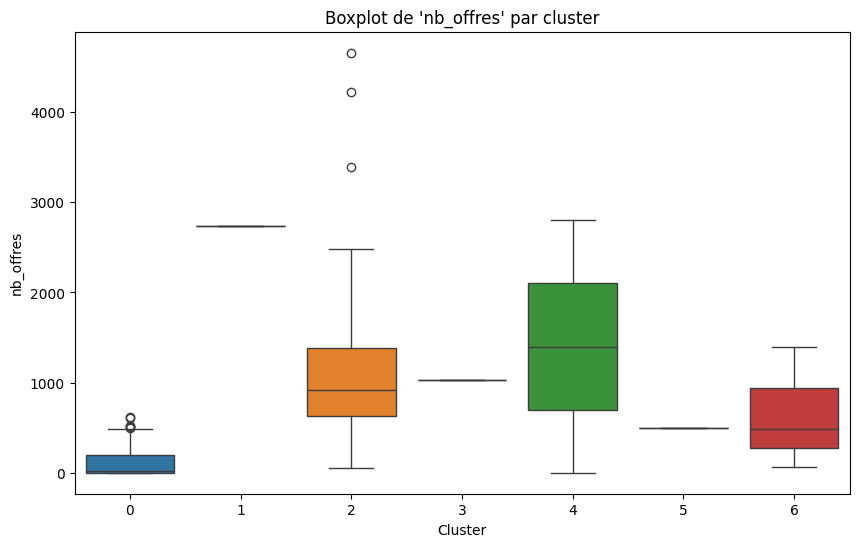

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\3057403895.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_agences,


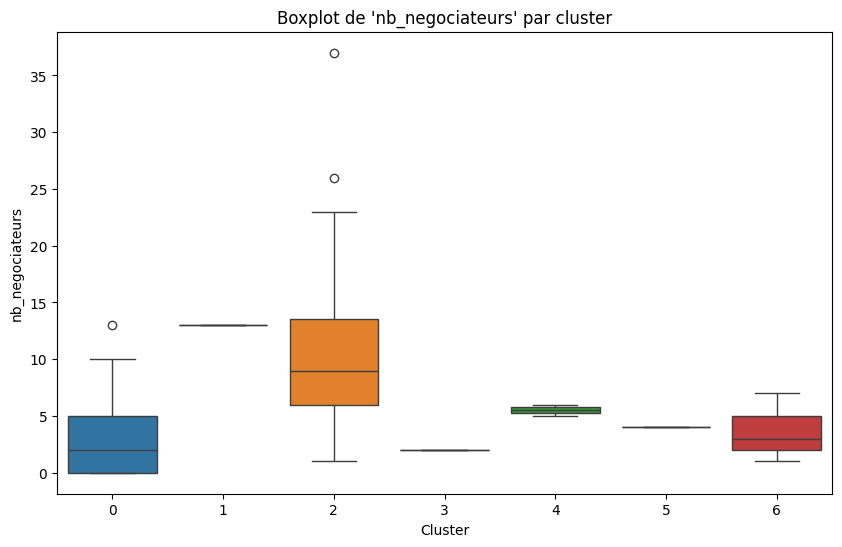

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\3057403895.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_agences,


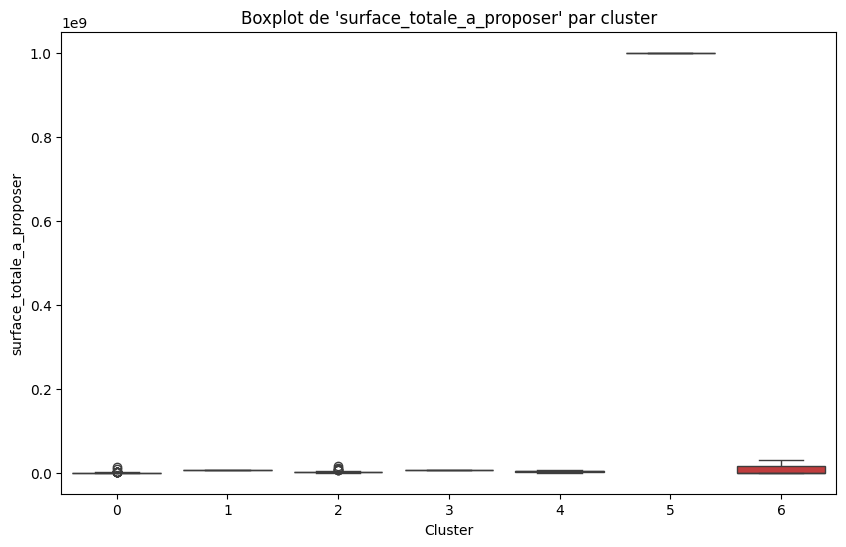

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\3057403895.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_agences,


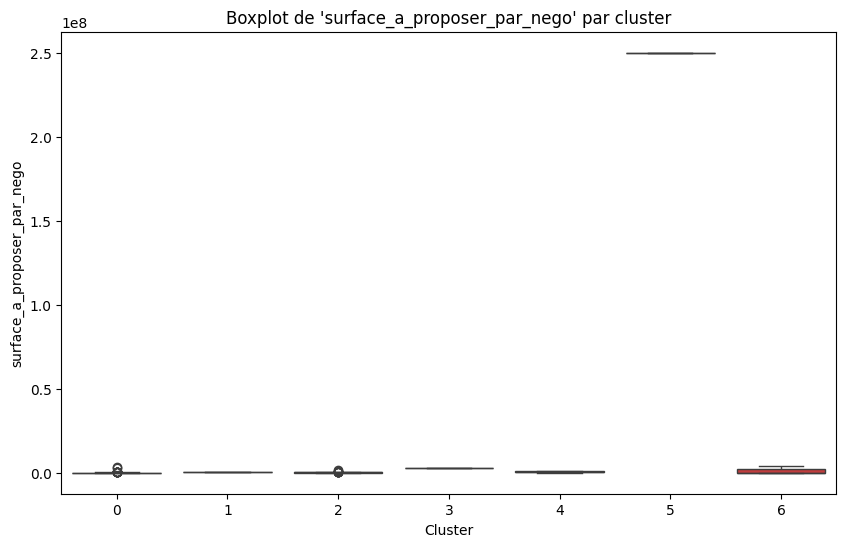

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\3057403895.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_agences,


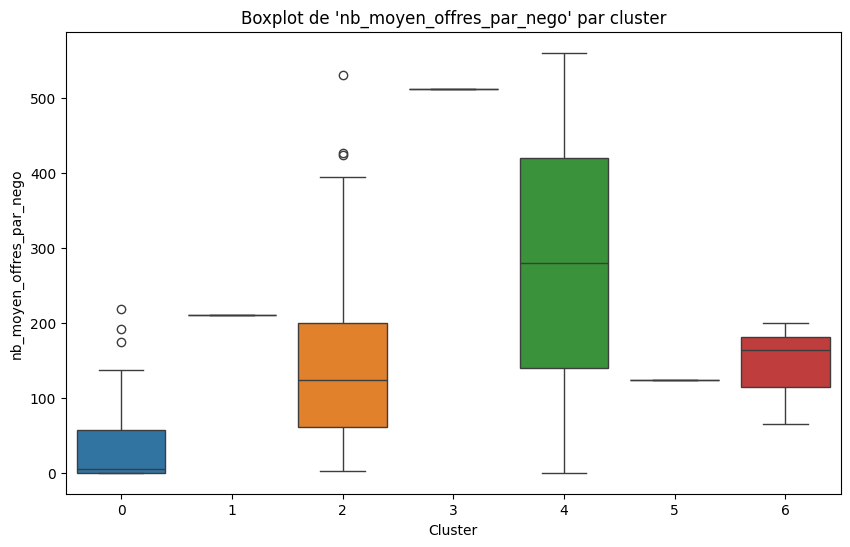

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\3057403895.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_agences,


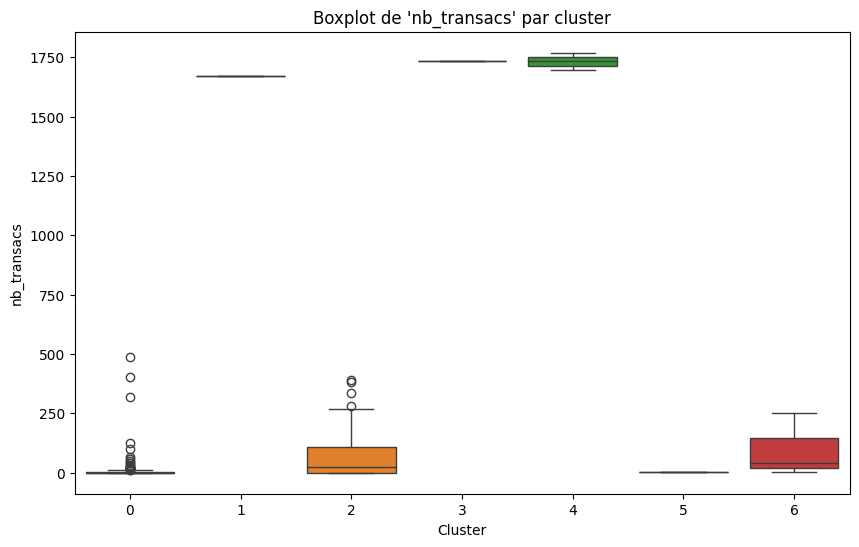

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\3057403895.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_agences,


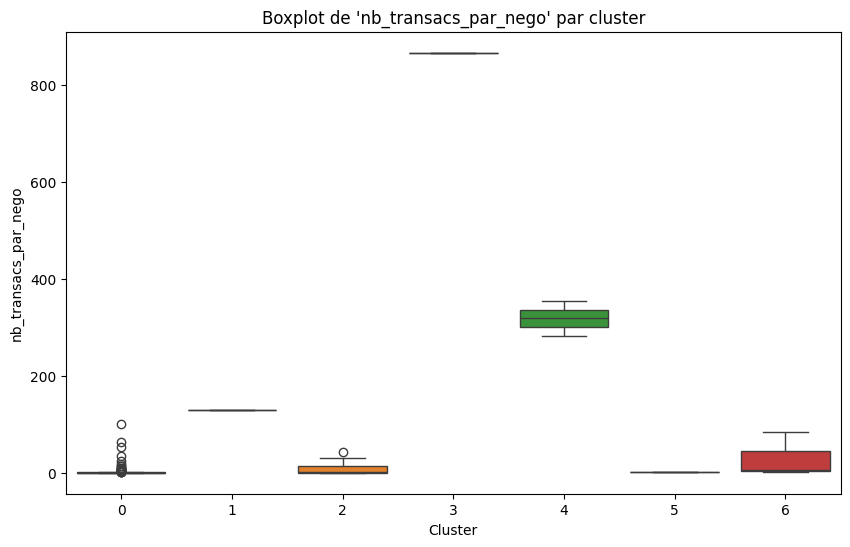

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\3057403895.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_agences,


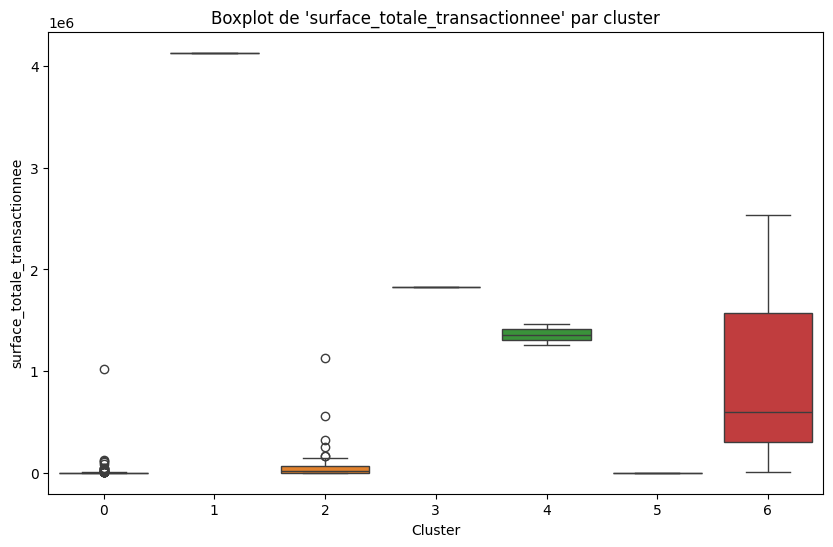

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\3057403895.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_agences,


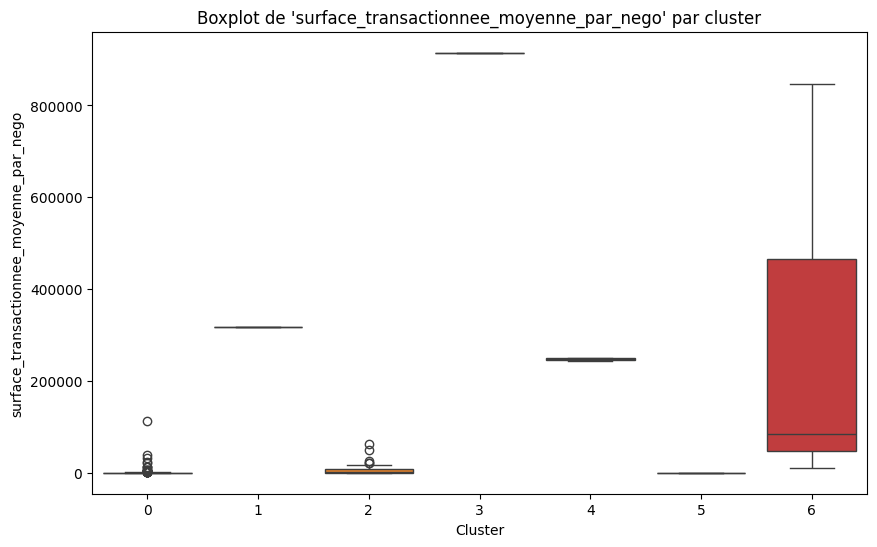

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\3057403895.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_agences,


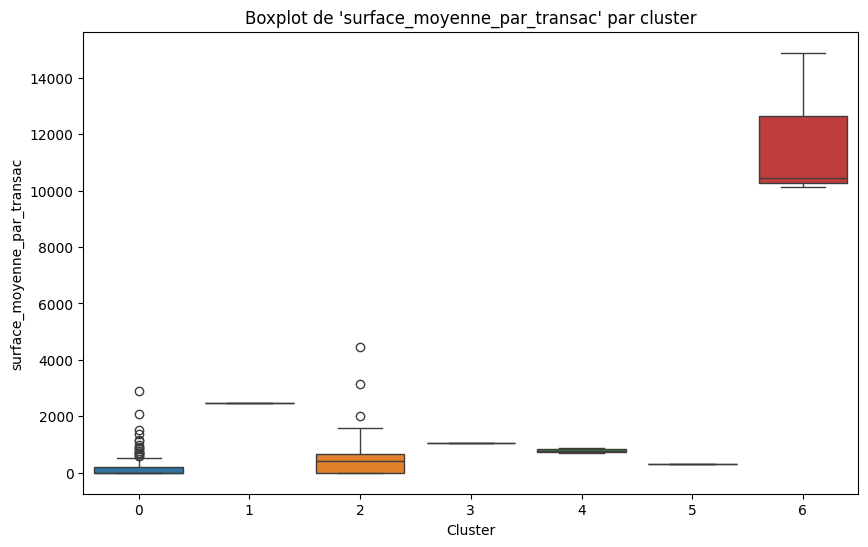

In [344]:
for feature in colonnes_features_clustering_agences :
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=dataset_agences, 
                x="cluster", 
                y=feature, 
                palette="tab20")
    
    plt.title(f"Boxplot de '{feature}' par cluster")
    plt.xlabel("Cluster")
    plt.ylabel(feature)
    plt.show()

Le cluster 6, composé d'une seule agence, écrase tous les autres en termes de surface à proposer. Il a plutôt beaucoup d'offres mais rien de ridiculement grand. Le cluster 5, composé de seulement deux agences, vend des immenses surfaces, ce qui en fait sa spécificité, aucun autre cluster ne s'approche de cette gamme de surfaces, si ce n'est le cluster 4, composé d'une seule agence, dont la spécificité principale est aussi les grandes surfaces. Cette agence diffère des deux du cluster 5 dans l'intensité de son activité : beaucoup plus de transactions. Le cluster 3, composé d'une vingtaine de membres, est un cluster d'agences qui multiplie les offres. Les autres clusters présentent des nombres d'offres dérisoires à côté de celui du cluster 3. Le cluster 2, composé de 4 membres, présente aussi un très grand catalogue d'offres, mais à la différence du cluster 3, il se distingue des autres agences du dataset par l'intensité de l'activité, avec un grand nombre de transactions. Le cluster 1 fonctionne lui à l'économie : peu de négociateurs et peu d'offres, peu de surface à proposer, mais beaucoup de transactions. C'est dans ce cluster que l'on retrouve la grande majorité des agences. Le cluster 0 enfin est le deuxième plus peuplé. Ce sont des agences qui disposent de beaucoup de négociateurs et de beaucoup d'offres mais dont l'activité reste légère, avec très peu de transactions comparé aux autres clusters. 

En résumé : 

Cluster 0 : Beaucoup d'offres et de négociateurs, faible activité

Cluster 1 : Peu d'offres et de négociateurs, forte activité

Cluster 2 : Beaucoup d'offres, forte activité

Cluster 3 : Immense catalogue d'offres

Cluster 4 : Grandes surfaces proposées

Cluster 5 : Grandes surfaces proposées

Cluster 6 : Leader du marché en termes de surfaces proposées

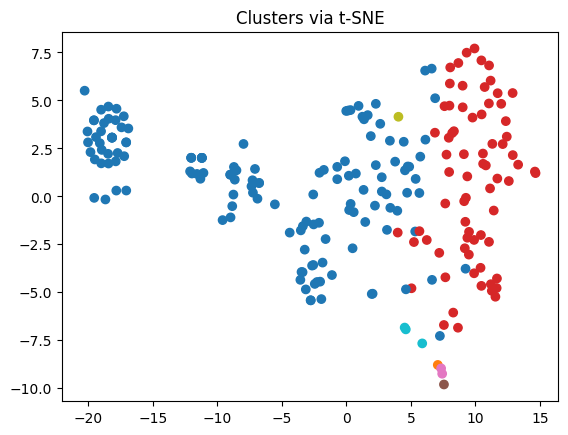

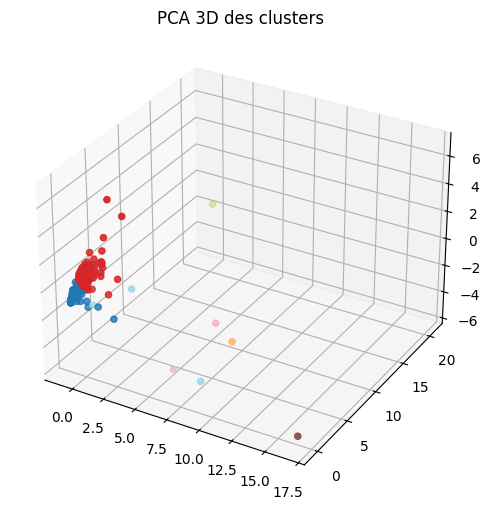

In [345]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=dataset_agences["cluster"], cmap="tab10")
plt.title("Clusters via t-SNE")
plt.show()

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2],
           c=dataset_agences["cluster"], cmap="tab20", s=20)

ax.set_title("PCA 3D des clusters")
plt.show()

df_tsne = pd.DataFrame({
    "tsne_x": X_tsne[:, 0],
    "tsne_y": X_tsne[:, 1],
    "cluster": dataset_agences["cluster"].values
})

df_tsne.head()

conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=172.16.11.34;"
    "DATABASE=Superset;"
    "UID=quentin;"
    "PWD={Barbidur1;SQL}"
)

conn = pyodbc.connect(conn_str)
cursor = conn.cursor()

insert_query = """
    INSERT INTO cluster_agences_tsne (tsne_x, tsne_y, cluster)
    VALUES (?, ?, ?)
"""

data_to_insert = list(df_tsne.itertuples(index=False, name=None))

cursor.executemany(insert_query, data_to_insert)

conn.commit()
conn.close()

Une projection 3D dans le cas du clustering sur les agences perd inévitablement plus d'informations que dans le cas du clustering sur les négociateurs, ce qui est tout à fait attendu puisque l'on part d'un espace de dimension bien supérieur. On arrive tout de même à voir sur le graphique que les features séparent les points même cela reste moins évident à la lecture que dans le premier clustering. 

In [346]:
for feature in colonnes_features_clustering_agences :
    groups = [dataset_agences[dataset_agences.cluster == k][feature] for k in dataset_agences.cluster.unique()]
    stat, p = f_oneway(*groups)
    print(feature, ": p =", p)

for feature in colonnes_features_clustering_agences :
    groups = [dataset_agences[dataset_agences.cluster == k][feature] for k in dataset_agences.cluster.unique()]
    stat, p = kruskal(*groups)
    print(feature, ": p =", p)

nb_offres : p = 1.67258763975314e-29
nb_negociateurs : p = 1.4409547095727084e-21
surface_totale_a_proposer : p = 4.0821445125414194e-303
surface_a_proposer_par_nego : p = 0.0
nb_moyen_offres_par_nego : p = 1.1357014109032431e-22
nb_transacs : p = 2.1809912764451727e-104
nb_transacs_par_nego : p = 3.2040616063478118e-155
surface_totale_transactionnee : p = 3.9155013510817085e-73
surface_transactionnee_moyenne_par_nego : p = 4.3723652064004284e-60
surface_moyenne_par_transac : p = 4.153735702330755e-83
nb_offres : p = 1.1296421545204739e-26
nb_negociateurs : p = 4.6244438885951225e-17
surface_totale_a_proposer : p = 3.3886917384423855e-22
surface_a_proposer_par_nego : p = 1.817495944748781e-15
nb_moyen_offres_par_nego : p = 4.723269930584997e-17
nb_transacs : p = 1.1573437387391704e-10
nb_transacs_par_nego : p = 6.98583359950659e-09
surface_totale_transactionnee : p = 1.654705796127139e-11
surface_transactionnee_moyenne_par_nego : p = 2.245359505765951e-10
surface_moyenne_par_transac : 

On n'a que des p-values extrêmement faibles, voire carrément nulles, c'est très bon signe, cela veut dire que les deux tests ne permettent pas de rejeter l'hypothèse nulle selon laquelle les features ne séparent pas les clusters. 

**Clustering des groupes à présent**

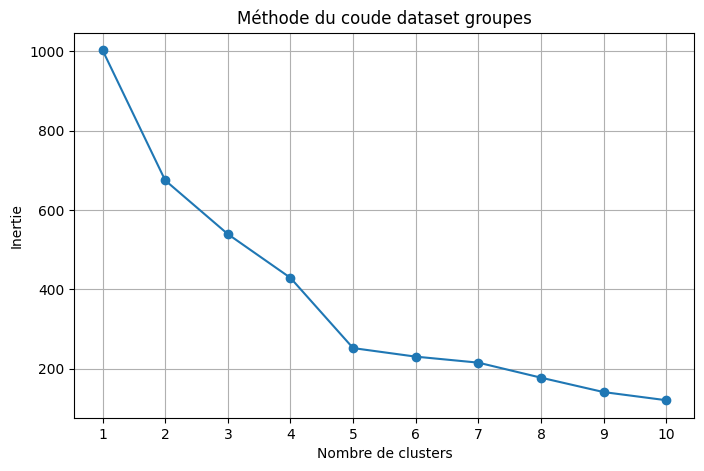

cluster
0    45
3    10
2     1
5     1
4     1
1     1
Name: count, dtype: int64


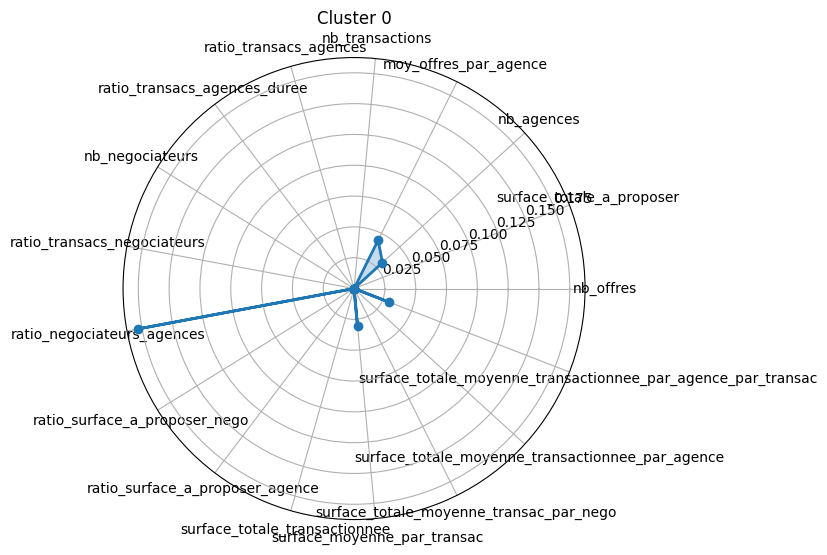

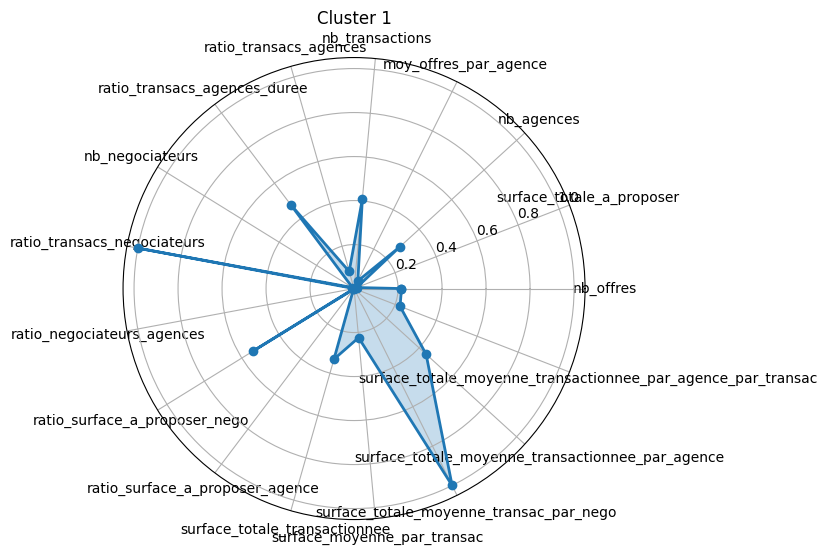

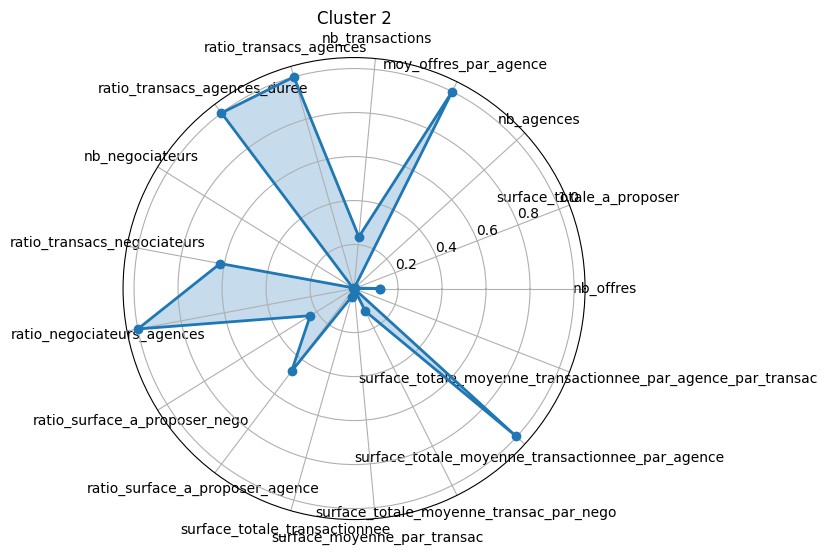

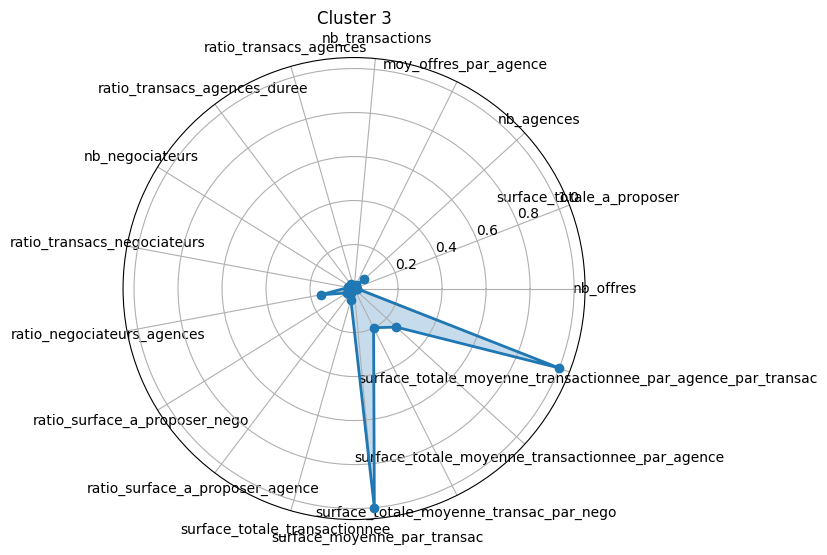

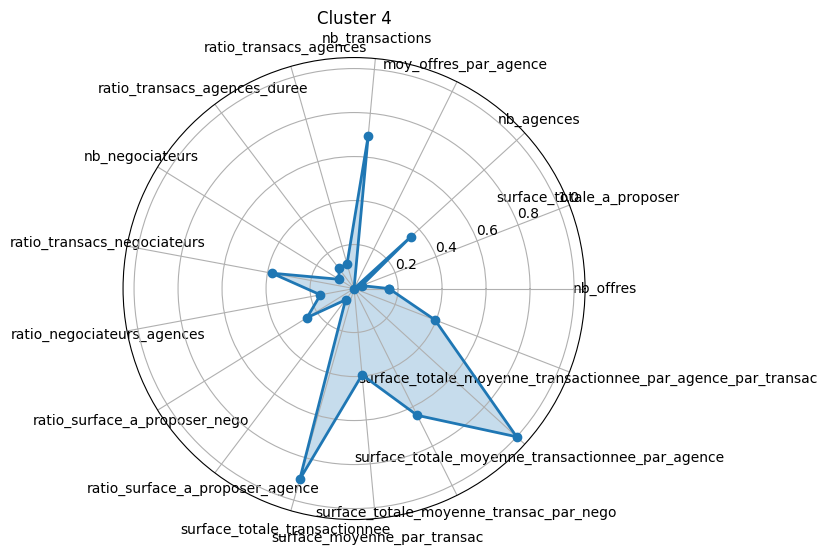

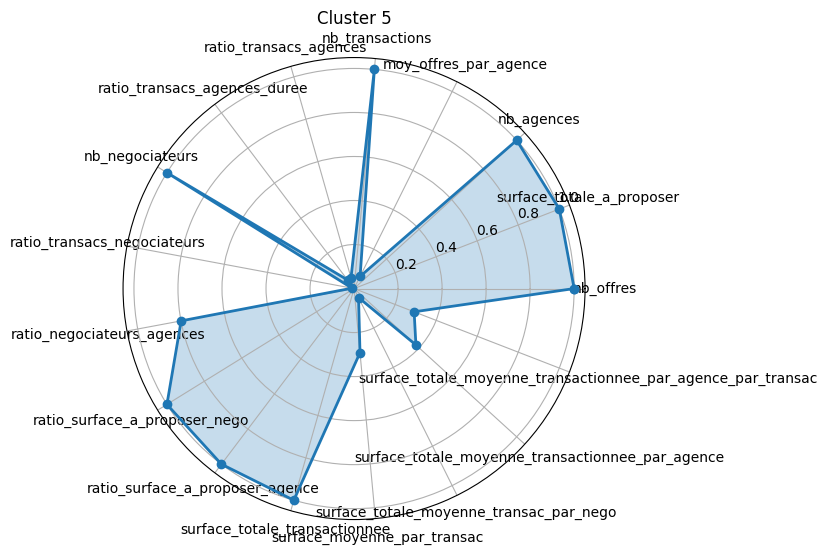

In [347]:
colonnes_features_clustering_groupes = [
    # 'gro_date_creation', 
    # 'gro_investissement',
    # 'gro_prospect', 
    # 'gro_livraisons_immeubles_bureaux',
    # 'gro_transactions_investissement', 
    # 'gro_transactions_retail',
    'nb_offres', 
    'surface_totale_a_proposer', 
    'nb_agences',
    'moy_offres_par_agence', 
    'nb_transactions', 
    'ratio_transacs_agences',
    'ratio_transacs_agences_duree',
    'nb_negociateurs',
    'ratio_transacs_negociateurs', 
    'ratio_negociateurs_agences',
    'ratio_surface_a_proposer_nego', 
    'ratio_surface_a_proposer_agence',
    'surface_totale_transactionnee', 
    'surface_moyenne_par_transac',
    'surface_totale_moyenne_transac_par_nego',
    'surface_totale_moyenne_transactionnee_par_agence',
    'surface_totale_moyenne_transactionnee_par_agence_par_transac'
]

inerties = []
k_range = range(1, 11)

X = dataset_groupes[colonnes_features_clustering_groupes]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

for k in k_range :
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inerties.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inerties, marker='o')
plt.xlabel('Nombre de clusters')
plt.ylabel('Inertie')
plt.title("Méthode du coude dataset groupes")
plt.xticks(k_range)
plt.grid(True)
plt.show()

k = 6
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X_scaled)

dataset_groupes['cluster'] = kmeans.labels_

print(dataset_groupes['cluster'].value_counts())

cluster_means = dataset_groupes.groupby('cluster')[colonnes_features_clustering_groupes].mean()
scaler = MinMaxScaler()
cluster_means_scaled = pd.DataFrame(scaler.fit_transform(cluster_means), columns=cluster_means.columns, index=cluster_means.index)

for cluster_id in cluster_means_scaled.index:
    plot_radar(cluster_id)

In [348]:
# Comme d'habitude, on jette un coup d'oeil aux statistiques descriptives des clusters

resume_moyennes = (
    dataset_groupes
    .groupby("cluster")[colonnes_features_clustering_groupes]
    .mean()
)

print(resume_moyennes)

            nb_offres  surface_totale_a_proposer  nb_agences  \
cluster                                                        
0          951.844444               1.786933e+06    2.777778   
1         7611.000000               1.551598e+07   17.000000   
2         4657.000000               9.105744e+06    1.000000   
3         1360.200000               5.089357e+06    4.600000   
4         5848.000000               4.120183e+07   21.000000   
5        31837.000000               1.065572e+09   58.000000   

         moy_offres_par_agence  nb_transactions  ratio_transacs_agences  \
cluster                                                                   
0                   470.196958      1896.377778              510.629762   
1                   447.705882     44606.000000             2623.882353   
2                  4657.000000     26611.000000            26611.000000   
3                   356.264474      3342.600000              551.975000   
4                   278.476190     74

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\939167803.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_groupes,


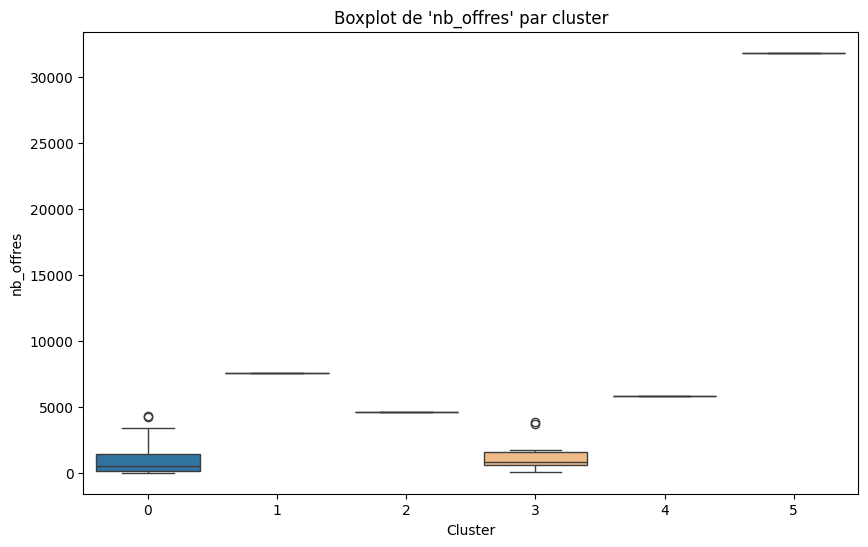

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\939167803.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_groupes,


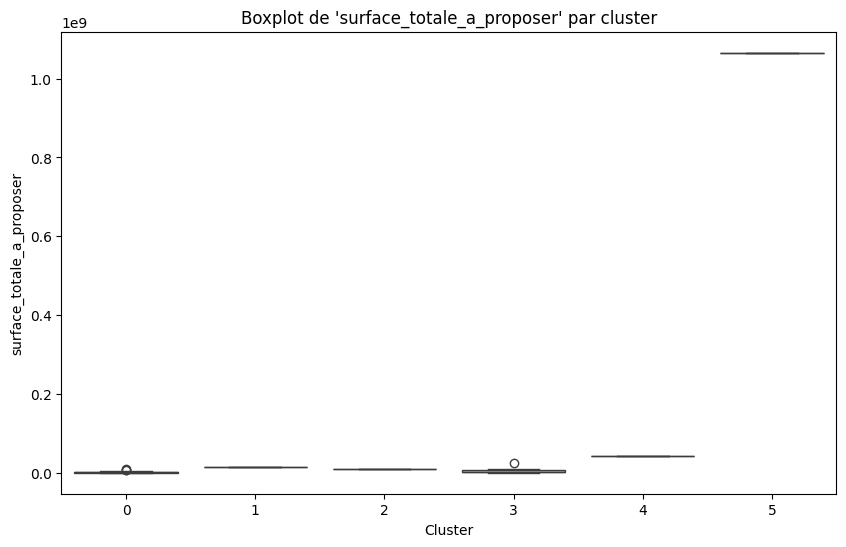

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\939167803.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_groupes,


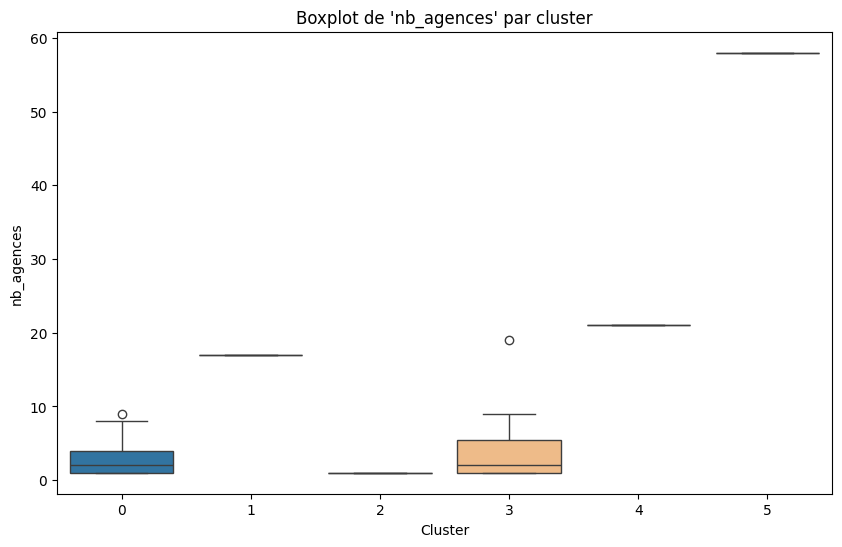

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\939167803.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_groupes,


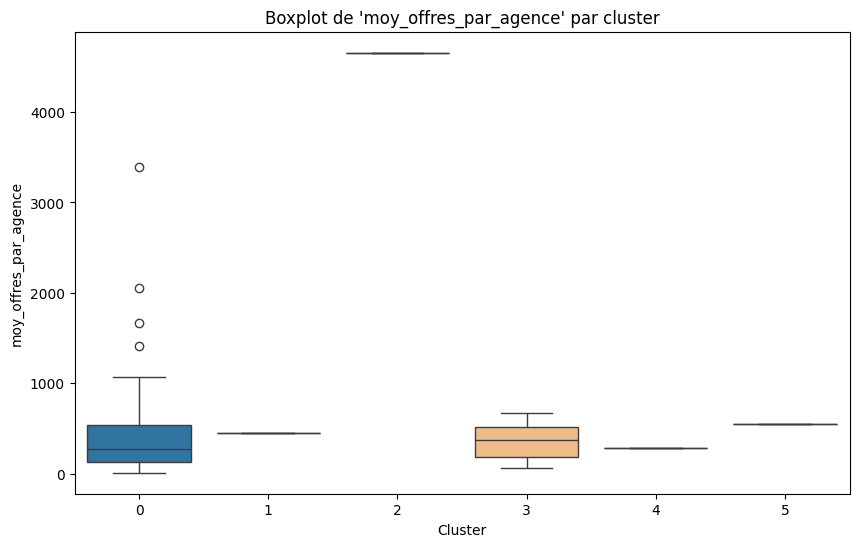

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\939167803.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_groupes,


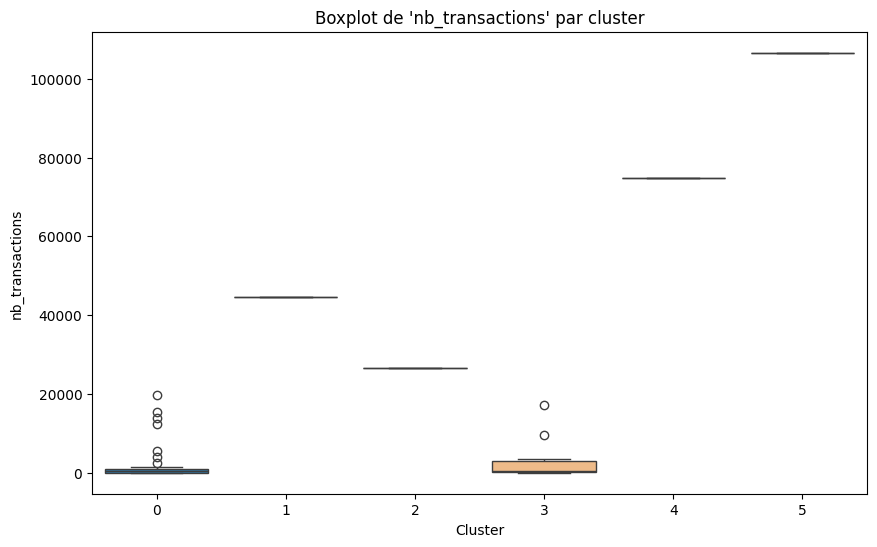

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\939167803.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_groupes,


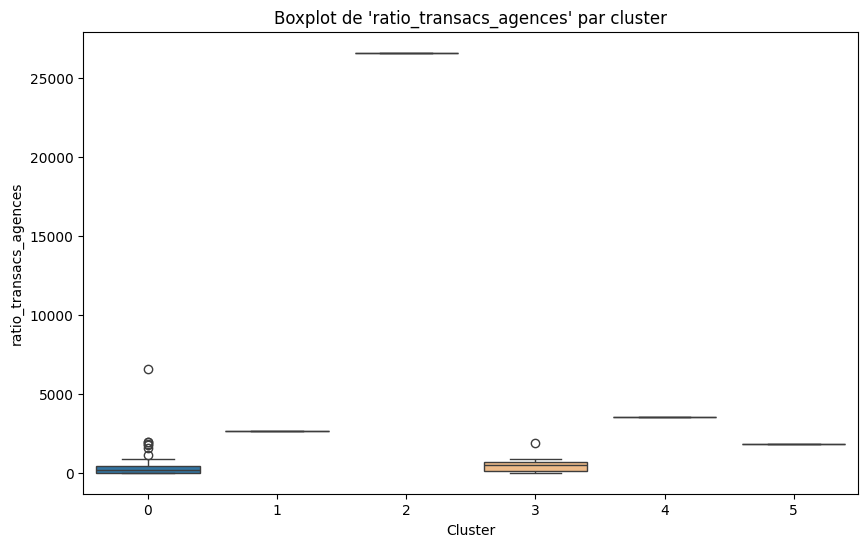

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\939167803.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_groupes,


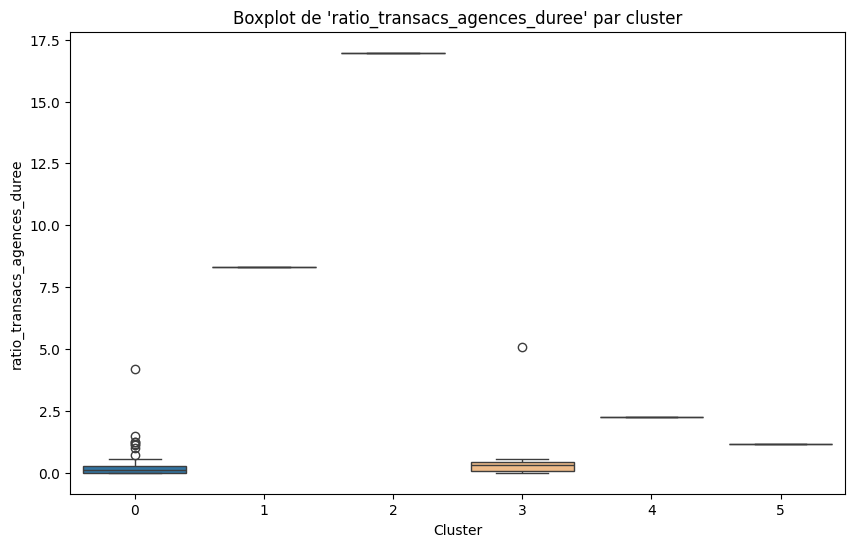

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\939167803.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_groupes,


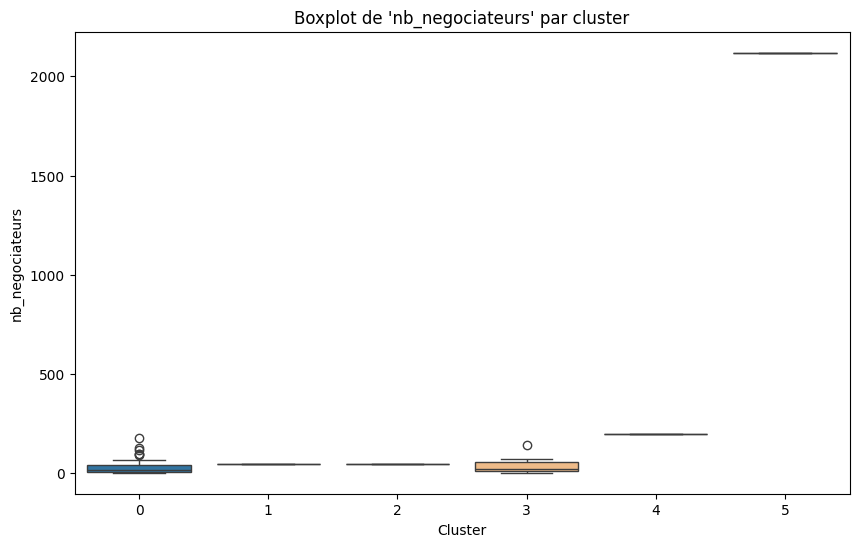

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\939167803.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_groupes,


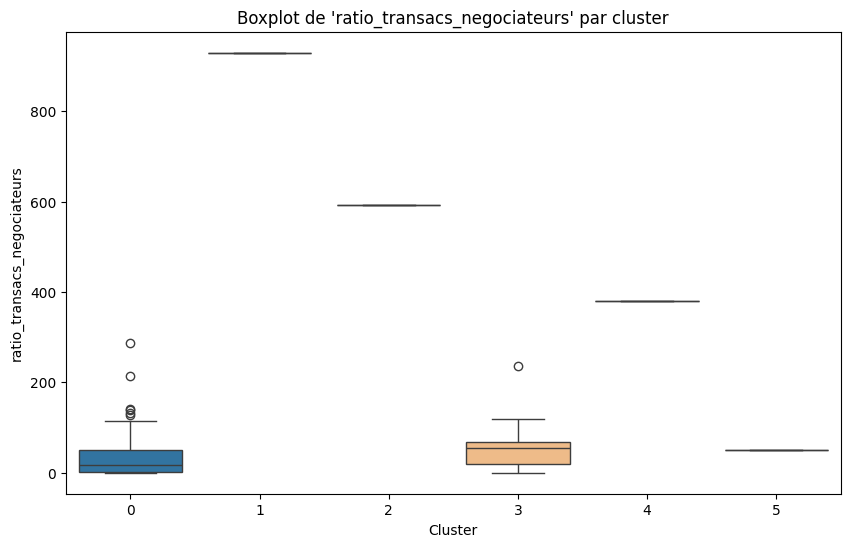

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\939167803.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_groupes,


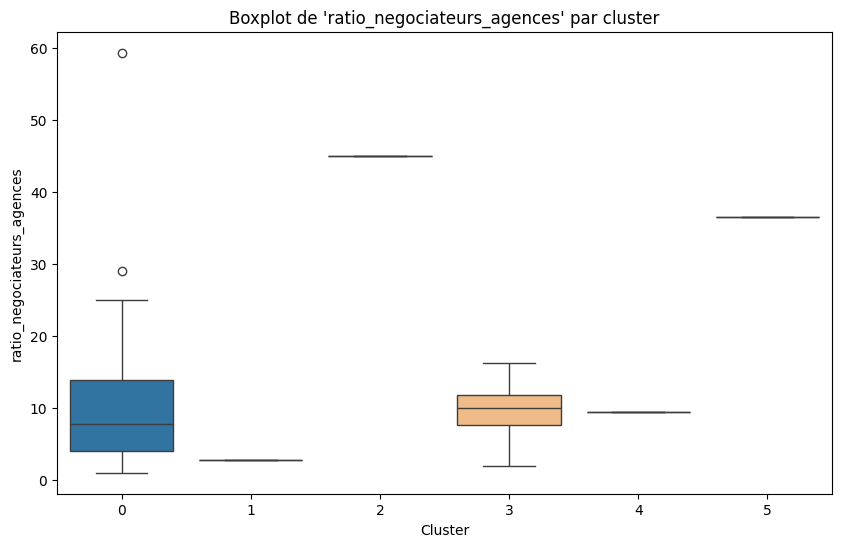

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\939167803.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_groupes,


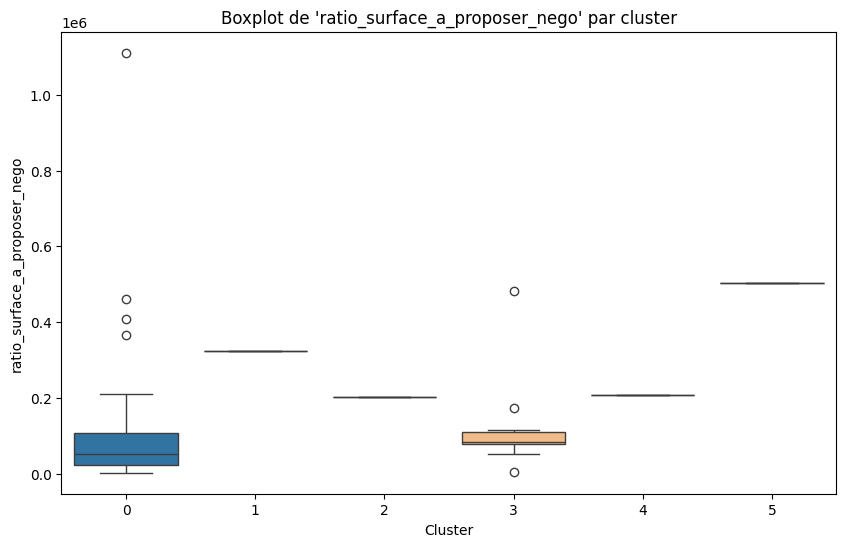

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\939167803.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_groupes,


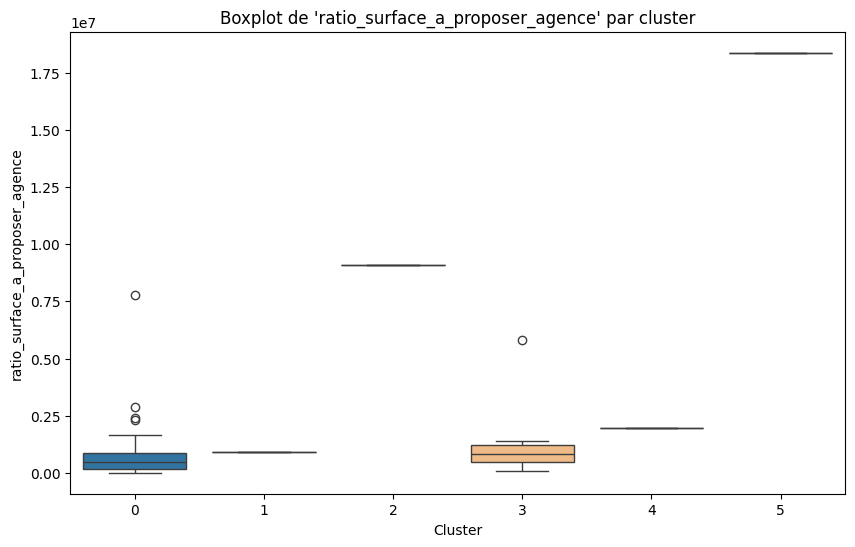

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\939167803.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_groupes,


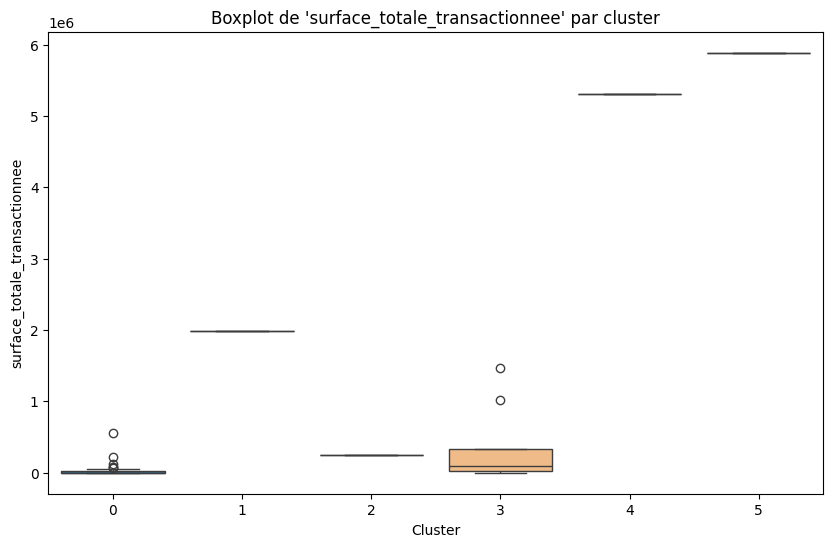

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\939167803.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_groupes,


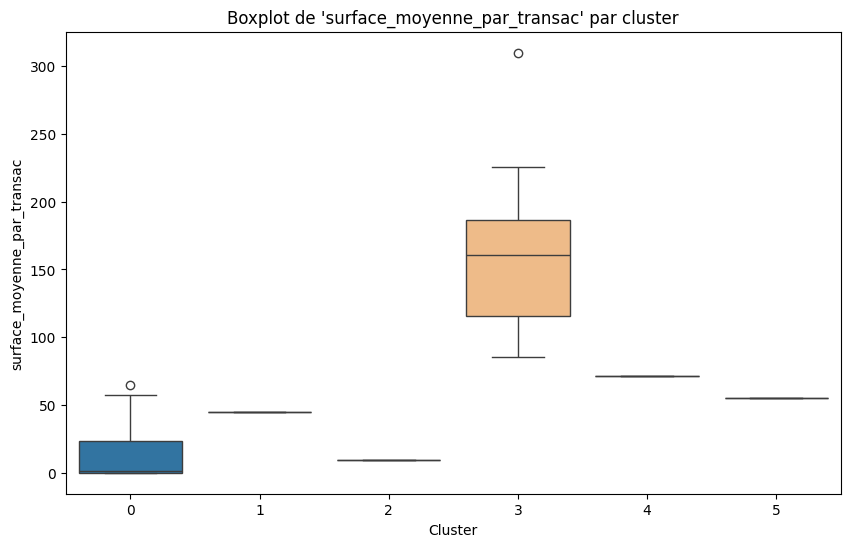

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\939167803.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_groupes,


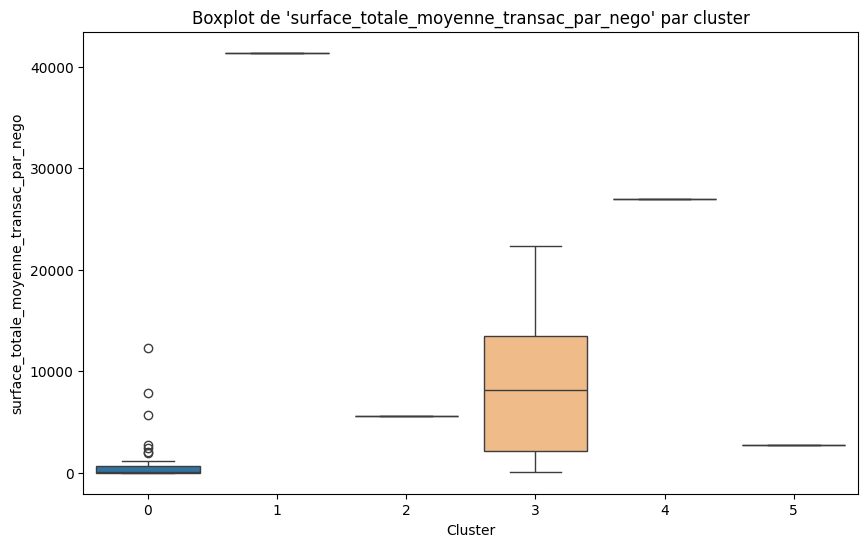

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\939167803.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_groupes,


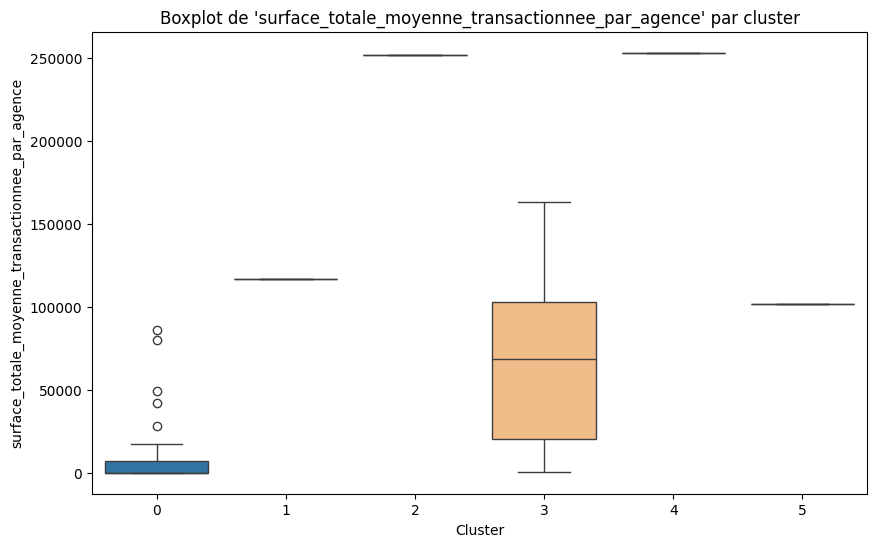

C:\Users\quent\AppData\Local\Temp\ipykernel_11952\939167803.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_groupes,


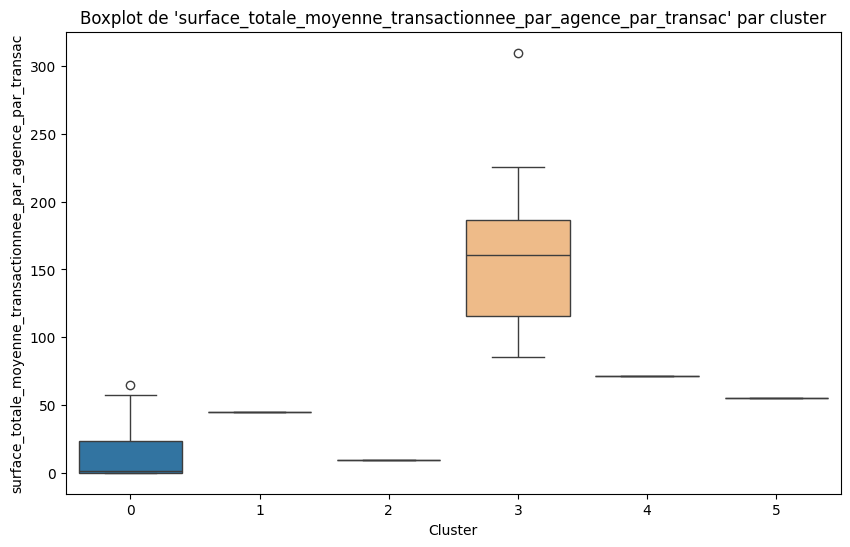

In [349]:
# Puis on affiche les boxplots pour plus de visibilité

for feature in colonnes_features_clustering_groupes :
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=dataset_groupes, 
                x="cluster", 
                y=feature, 
                palette="tab20")
    
    plt.title(f"Boxplot de '{feature}' par cluster")
    plt.xlabel("Cluster")
    plt.ylabel(feature)
    plt.show()

En résumé : 

Cluster 0 : 13 membres, pas très actifs, mais grandes surfaces.

Cluster 1 : 2 membres, grandes surfaces et négociateurs très actifs.

Cluster 2 : 1 membre, qui fait petit volume par petit volume, mais extrêmement actif.

Cluster 3 : 73 membres, beaucoup d'agences avec peu de négociateurs, peu d'activité individuellement, gèrent des grandes surfaces.

Cluster 4 : 1 membre, individuellement les agences et négociateurs ne sont pas les plus actifs, mais le catalogue d'offres est immense et vu le nombre de collaborateurs, ce groupe est leader du marché en nombre brut de transactions.

Cluster 5 : 1 membre, pas si actif, mais qui concentre ses collaborateurs au même endroit. 

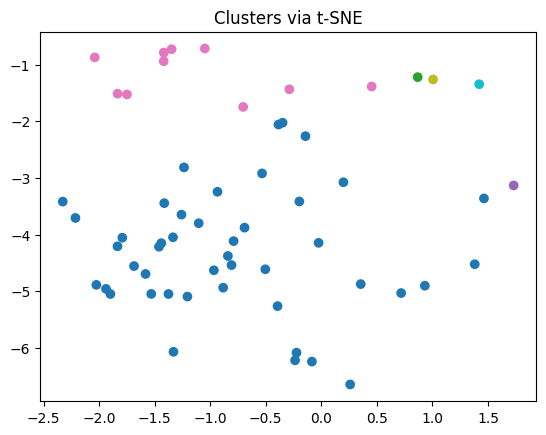

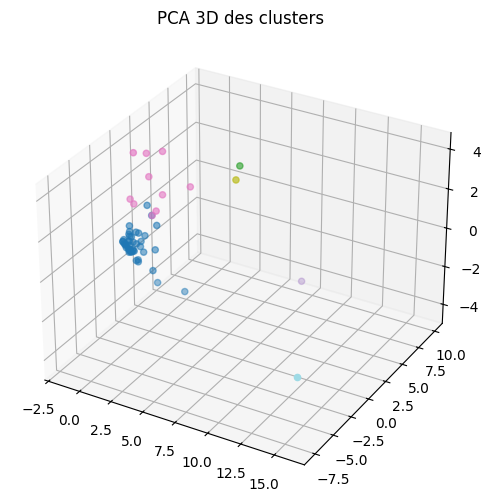

In [350]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=dataset_groupes["cluster"], cmap="tab10")
plt.title("Clusters via t-SNE")
plt.show()

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=dataset_groupes["cluster"], cmap="tab20", s=20)

ax.set_title("PCA 3D des clusters")
plt.show()

df_tsne = pd.DataFrame({
    "tsne_x": X_tsne[:, 0],
    "tsne_y": X_tsne[:, 1],
    "cluster": dataset_groupes["cluster"].values
})

df_tsne.head()

conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=172.16.11.34;"
    "DATABASE=Superset;"
    "UID=quentin;"
    "PWD={Barbidur1;SQL}"
)

conn = pyodbc.connect(conn_str)
cursor = conn.cursor()

insert_query = """
    INSERT INTO cluster_groupes_tsne (tsne_x, tsne_y, cluster)
    VALUES (?, ?, ?)
"""

data_to_insert = list(df_tsne.itertuples(index=False, name=None))

cursor.executemany(insert_query, data_to_insert)

conn.commit()
conn.close()

Au vu du nombre de features, on aurait pu s'attendre à une projection 2D et à une projection 3D plus difficilement lisible, mais finalement à la simple lecture graphique on parvient correctement à séparer les clusters. 

Comme d'habitude, on confirme cette observation par les deux tests statistiques.

In [351]:
for feature in colonnes_features_clustering_groupes :
    groups = [dataset_groupes[dataset_groupes.cluster == k][feature] for k in dataset_groupes.cluster.unique()]
    stat, p = f_oneway(*groups)
    print(feature, ": p =", p)

for feature in colonnes_features_clustering_groupes :
    groups = [dataset_groupes[dataset_groupes.cluster == k][feature] for k in dataset_groupes.cluster.unique()]
    stat, p = kruskal(*groups)
    print(feature, ": p =", p)

nb_offres : p = 1.1316382342864936e-30
surface_totale_a_proposer : p = 2.460223138462709e-83
nb_agences : p = 8.674978042253802e-22
moy_offres_par_agence : p = 4.050265707943397e-07
nb_transactions : p = 8.715606235952827e-31
ratio_transacs_agences : p = 1.2231942119609206e-28
ratio_transacs_agences_duree : p = 2.0163127167855994e-23
nb_negociateurs : p = 3.7041008370821676e-44
ratio_transacs_negociateurs : p = 7.521370698687474e-20
ratio_negociateurs_agences : p = 0.001055843912934685
ratio_surface_a_proposer_nego : p = 0.27142043324956044
ratio_surface_a_proposer_agence : p = 5.195422807460784e-17
surface_totale_transactionnee : p = 1.1743420722307967e-35
surface_moyenne_par_transac : p = 1.8639336978585456e-15
surface_totale_moyenne_transac_par_nego : p = 1.737323478681494e-15
surface_totale_moyenne_transactionnee_par_agence : p = 4.775100727977462e-15
surface_totale_moyenne_transactionnee_par_agence_par_transac : p = 1.8639336978585456e-15
nb_offres : p = 0.037885054831390916
surfa

Toutes les p-values des deux tests sont extrêmement faibles : le clustering est concluant et les features permettent effectivement de séparer les clusters. 

In [352]:
print(dataset_negociateurs.columns)
print(dataset_agences.columns)
print(dataset_groupes.columns)

Index(['negociateur_id', 'agence_id', 'neg_date_creation',
       'surface_totale_a_proposer_nego', 'nb_transacs',
       'surface_totale_transactionnee',
       'ratio_surface_totale_transactionnee_temps_activite',
       'ratio_nb_transacs_temps_activite', 'surface_moyenne_par_transac',
       'cluster'],
      dtype='object')
Index(['agence_id', 'groupe_id', 'nb_offres', 'nb_negociateurs',
       'surface_totale_a_proposer', 'surface_a_proposer_par_nego',
       'nb_moyen_offres_par_nego', 'nb_transacs', 'nb_transacs_par_nego',
       'surface_totale_transactionnee',
       'surface_transactionnee_moyenne_par_nego',
       'surface_moyenne_par_transac', 'cluster_nego_majoritaire', 'cluster'],
      dtype='object')
Index(['groupe_id', 'gro_nom', 'gro_date_creation', 'nb_offres',
       'surface_totale_a_proposer', 'nb_agences', 'moy_offres_par_agence',
       'nb_transactions', 'ratio_transacs_agences',
       'ratio_transacs_agences_duree', 'nb_negociateurs',
       'ratio_transacs_

In [353]:
# On modifie les noms des colonnes pour les formater "logipro"

dataset_negociateurs = dataset_negociateurs.rename(columns={
    'surface_totale_a_proposer_nego' : 'cluster_neg_surface_a_proposer', 
    'nb_transacs' : 'cluster_neg_nb_transacs',
    'surface_totale_transactionnee' : 'cluster_neg_surface_transigee',
    'ratio_surface_totale_transactionnee_temps_activite' : 'cluster_neg_surface_transigee_ratio_temps',
    'ratio_nb_transacs_temps_activite' : 'cluster_neg_transacs_ratio_temps', 
    'surface_moyenne_par_transac' : 'cluster_neg_surface_moyenne_transac',
    'cluster' : 'cluster_neg_cluster'
})

dataset_agences = dataset_agences.rename(columns={
    'nb_offres' : 'cluster_age_nb_offres', 
    'nb_negociateurs' : 'cluster_age_nb_negos',
    'surface_totale_a_proposer' : 'cluster_age_surface_proposee_agence', 
    'surface_a_proposer_par_nego' : 'cluster_age_surface_proposee_nego',
    'nb_moyen_offres_par_nego' : 'cluster_age_nb_offres_nego', 
    'nb_transacs' : 'cluster_age_nb_transacs_agence', 
    'nb_transacs_par_nego' : 'cluster_age_nb_transacs_nego',
    'surface_totale_transactionnee' : 'cluster_age_surface_transigee_agence',
    'surface_transactionnee_moyenne_par_nego' : 'cluster_age_surface_transigee_nego',
    'surface_moyenne_par_transac' : 'cluster_age_surface_transac',
    'cluster_nego_majoritaire' : 'cluster_age_cluster_nego_majoritaire', 
    'cluster' : 'cluster_age_cluster'
})

dataset_groupes = dataset_groupes.rename(columns={
    'nb_offres' : 'cluster_gro_nb_offres', 
    'surface_totale_a_proposer' : 'cluster_gro_surface_proposee', 
    'nb_agences' : 'cluster_gro_nb_agences',
    'moy_offres_par_agence' : 'cluster_gro_nb_offres_agences', 
    'nb_transactions' : 'cluster_gro_nb_transacs',
    'ratio_transacs_agences' : 'cluster_gro_transac_ratio_agence',
    'ratio_transacs_agences_duree' : 'cluster_gro_transac_ratio_agence_ratio_temps',
    'nb_negociateurs' : 'cluster_gro_nb_negociateurs',
    'ratio_transacs_negociateurs' : 'cluster_gro_transacs_ratio_negociateurs',
    'ratio_negociateurs_agences' : 'cluster_gro_negociateurs_ratio_agences',
    'ratio_surface_a_proposer_nego' : 'cluster_gro_surface_proposee_ratio_nego',
    'ratio_surface_a_proposer_agence' : 'cluster_gro_surface_proposee_ratio_agence',
    'surface_totale_transactionnee' : 'cluster_gro_surface_transigee',
    'surface_moyenne_par_transac' : 'cluster_gro_surface_transigee_ratio_nb_transacs',
    'surface_totale_moyenne_transac_par_nego' : 'cluster_gro_surface_moyenne_par_transac_ratio_nb_negos',
    'surface_totale_moyenne_transactionnee_par_agence' : 'cluster_gro_surface_transigee_ratio_nb_agences',
    'surface_totale_moyenne_transactionnee_par_agence_par_transac' : 'cluster_gro_surface_moyenne_transigee_ratio_agences_ratio_transacs',
    'cluster' : 'cluster_gro_cluster'
})

In [354]:
print(dataset_negociateurs.columns)
print(dataset_agences.columns)
print(dataset_groupes.columns)

Index(['negociateur_id', 'agence_id', 'neg_date_creation',
       'cluster_neg_surface_a_proposer', 'cluster_neg_nb_transacs',
       'cluster_neg_surface_transigee',
       'cluster_neg_surface_transigee_ratio_temps',
       'cluster_neg_transacs_ratio_temps',
       'cluster_neg_surface_moyenne_transac', 'cluster_neg_cluster'],
      dtype='object')
Index(['agence_id', 'groupe_id', 'cluster_age_nb_offres',
       'cluster_age_nb_negos', 'cluster_age_surface_proposee_agence',
       'cluster_age_surface_proposee_nego', 'cluster_age_nb_offres_nego',
       'cluster_age_nb_transacs_agence', 'cluster_age_nb_transacs_nego',
       'cluster_age_surface_transigee_agence',
       'cluster_age_surface_transigee_nego', 'cluster_age_surface_transac',
       'cluster_age_cluster_nego_majoritaire', 'cluster_age_cluster'],
      dtype='object')
Index(['groupe_id', 'gro_nom', 'gro_date_creation', 'cluster_gro_nb_offres',
       'cluster_gro_surface_proposee', 'cluster_gro_nb_agences',
       'clust

In [355]:
dataset_negociateurs = dataset_negociateurs.drop(columns=['neg_date_creation'])

dataset_agences = dataset_agences.drop(columns=['cluster_age_cluster_nego_majoritaire'])

dataset_groupes = dataset_groupes.drop(columns=['gro_date_creation'])

In [356]:
# On finit par un enregistrement des données pour afficher des graphiques dans Superset

dataset_negociateurs.to_excel("negociateurs.xlsx", index=False)
dataset_agences.to_excel("agences.xlsx", index=False)
dataset_groupes.to_excel("groupes.xlsx", index=False)

In [ ]:
conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=172.16.11.34;"
    "DATABASE=Superset;"
    "UID=quentin;"
    "PWD={Barbidur1;SQL}"
)

conn = pyodbc.connect(conn_str)
cursor = conn.cursor()

# On fait d'abord pour les groupes
colonnes = dataset_groupes.columns.tolist()

placeholders = ','.join(['?' for _ in colonnes])
columns_str = ','.join(colonnes)

sql = f"INSERT INTO cluster_gro ({columns_str}) VALUES ({placeholders})"

cursor.execute("DELETE FROM cluster_gro")
cursor.execute("DELETE FROM cluster_age")
cursor.execute("DELETE FROM cluster_neg")

for row in dataset_groupes.itertuples(index=False):
    cursor.execute(sql, *row)

# Puis pour les agences
colonnes = dataset_agences.columns.tolist()

placeholders = ','.join(['?' for _ in colonnes])
columns_str = ','.join(colonnes)

sql = f"INSERT INTO cluster_age ({columns_str}) VALUES ({placeholders})"

for row in dataset_agences.itertuples(index=False):
    cursor.execute(sql, *row)

# Et enfin pour les negociateurs
colonnes = dataset_negociateurs.columns.tolist()

placeholders = ','.join(['?' for _ in colonnes])
columns_str = ','.join(colonnes)

sql = f"INSERT INTO cluster_neg ({columns_str}) VALUES ({placeholders})"

for row in dataset_negociateurs.itertuples(index=False):
    cursor.execute(sql, *row)

In [ ]:
cursor.execute("DELETE FROM cluster_groupes_heatmap")
cursor.execute("DELETE FROM cluster_agences_heatmap")
cursor.execute("DELETE FROM cluster_negociateurs_heatmap")

dataset_groupes = dataset_groupes.drop(columns=['groupe_id', 'gro_nom'])
corr_matrix = dataset_groupes.corr(method='pearson')

# On met dans le format superset
corr_long = corr_matrix.reset_index().melt(id_vars='index')
corr_long.columns = ['x', 'y', 'correlation']
corr_long.to_excel("matrice_de_correlation_clustering_groupes.xlsx")

cursor.executemany(
    "INSERT INTO cluster_groupes_heatmap (x, y, correlation) VALUES (?, ?, ?)",
    corr_long.values.tolist()
)

dataset_agences = dataset_agences.drop(columns=['agence_id', 'groupe_id'])
corr_matrix = dataset_agences.corr(method='pearson')
corr_long = corr_matrix.reset_index().melt(id_vars='index')
corr_long.columns = ['x', 'y', 'correlation']
corr_long.to_excel("matrice_de_correlation_clustering_agences.xlsx")

cursor.executemany(
    "INSERT INTO cluster_agences_heatmap (x, y, correlation) VALUES (?, ?, ?)",
    corr_long.values.tolist()
)

dataset_negociateurs = dataset_negociateurs.drop(columns=['agence_id', 'negociateur_id'])
corr_matrix = dataset_negociateurs.corr(method='pearson')
corr_long = corr_matrix.reset_index().melt(id_vars='index')
corr_long.columns = ['x', 'y', 'correlation']
corr_long.to_excel("matrice_de_correlation_clustering_negociateurs.xlsx")

cursor.executemany(
    "INSERT INTO cluster_negociateurs_heatmap (x, y, correlation) VALUES (?, ?, ?)",
    corr_long.values.tolist()
)

conn.commit()
conn.close()